# Проект. Исследование стартапов

Автор: Ангелина Гольцева

Дата: 08.12.2025

## Введение

**Цель проекта** - исследование динамики и структуры финансирования стартапов и оценка инвестиционных стратегий.

**Задачи проекта:**

- Ознакомиться с данными - оценить количество строк и столбцов и их наименования;
- Предобработать данные для анализа - привести к корректному типу, обнаружить и обработать пропуски, обнаружить и избавиться от дублирующих записей в датасетах;
- Разделить компании по срокам финансирования и сегментам рынка;
- Проанализировать выбросы по сегментам, определить границы рассматриваемого периода;
- Изучить типы финансирования по объему и популярности;
- Выявить динамику предоставления финансирования по годам, а так же динамику финансирования растущих в 2014 году массовых сегментов рынка;
- Оценить типы финансирования по доли возвращенных средств;
- Сформулировать промежуточные выводы и итоговую рекомендацию.

## Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.


### Вывод общей информации

In [1]:
!pip install missingno -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

----

**Выгрузка и обзор данных**

In [3]:
cb_investments = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)

In [4]:
cb_returns = pd.read_csv('/datasets/cb_returns.csv')

In [5]:
pd.set_option('display.max_columns', None)
cb_investments.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,1.0,NaN,1636-09-08,NaN,NaN,1636.0,2014-01-06,NaN,2014-01-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,1.0,NaN,1785-01-01,NaN,NaN,1785.0,2014-05-15,NaN,2014-05-15,0.0,2000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,1.0,1.0,1802-07-19,NaN,NaN,1802.0,2009-07-02,2009-07-02,2009-07-02,0.0,9000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,3.0,0.0,1817-01-01,NaN,NaN,1817.0,2013-11-21,2013-11-21,2014-11-03,0.0,0.0,0.0,1600000.0,0.0,0.0,0.0,6100000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,1.0,NaN,1826-01-01,NaN,NaN,1826.0,2014-01-14,NaN,2014-01-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,540000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
cb_investments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

Датасет `cb_investments` содержит 54294 строки и 40 столбцов. На основании информации о датасете выявлено, что во всех столбцах датасета содержатся пропуски, а наименования некоторых столбцов требуют нормализации. Также целесообразно привести значения в числовых столбцах и столбцах с датами к корректным типам.

In [7]:
cb_returns

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.00,0.20,0.00
1,2001,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.00,0.46,0.00
2,2002,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.00,0.06,0.00
3,2003,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.00,0.08,0.00
4,2004,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.00,0.55,0.00
5,2005,26.60,2628.92,0.00,9.51,0.02,35.09,31.06,0.0,2.40,3.51,0.00,0.05,0.00
6,2006,61.81,3100.18,0.19,46.74,1.78,113.21,47.75,0.0,16.67,20.58,0.00,0.12,0.00
7,2007,70.41,3585.37,0.01,55.37,3.22,125.68,164.51,0.0,88.81,24.36,0.00,0.57,0.00
8,2008,89.72,2717.02,0.03,41.02,1.71,397.54,102.83,0.0,130.38,84.28,0.00,0.47,0.00
9,2009,160.21,2501.29,0.18,37.50,2.25,394.10,97.21,0.0,203.70,76.76,0.00,0.12,0.02


In [8]:
cb_returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


Датасет `cb_returns` содержит 15 строк и 14 столбцов. На основании информаци о датасете выявлено, что в датасете отсутствуют пропущенные значения. Наименования столбцов соответствуют содержащимся в них данным, не требуют нормализации. Значения в столбцах представлены корректными типами данных.

----

**Обзор данных:**
- датасет `cb_investments` содержит 54294 строки и 40 столбцов. Во всех столбцах содержатся пропуски. Наименования столбцов соответствуют содержимому, требуют нормализации. Необходимо преобразование типов данных в столбцах с числовыми значениями и датами.
- датасет `cb_returns` содержит 15 строк и 14 столбцов. Пропуски в датасете отсутствуют. Наименования столбцов и типы данных соответствуют содержимому столбцов.

### Предобработка данных

Создам копию датасета до преобразования для возможности проверить сделанные изменения после предобработки:

In [9]:
temp = cb_investments.copy()

Приведу наименования столбцов обоих датасетов к нижнему регистру и уберу лишние пробелы:

In [10]:
cb_investments.columns = cb_investments.columns.str.lower()
cb_investments.columns = cb_investments.columns.str.strip()
cb_returns.columns = cb_returns.columns.str.strip()

----

**Обработка числовых данных**

In [11]:
cb_investments['funding_total_usd'] = cb_investments['funding_total_usd'].str.replace(',','')
cb_investments['funding_total_usd'] = pd.to_numeric(cb_investments['funding_total_usd'], errors='coerce')

**Обработка данных даты и времени**

In [12]:
date = ['founded_at','first_funding_at','mid_funding_at','last_funding_at']

for col in date:
    cb_investments[col] = pd.to_datetime(cb_investments[col], errors='coerce')

In [13]:
cb_returns = cb_returns.set_index('year')

**Обработка текстовых данных**

In [14]:
def norm_data_low(x):
    x = str(x).lower().strip()
    return(x)

def norm_data_up(x):
    x = str(x).upper().strip()
    return(x)

In [15]:
text_cols_low = ['name','category_list','market','status','region','city','country_code','state_code']
for col in text_cols_low:
    cb_investments[col] = cb_investments[col].apply(norm_data_low)

----

**Обработка дубликатов и пропусков**

In [16]:
duplicates_investments = cb_investments.duplicated(subset=None, keep='first').sum()
duplicates_returns = cb_returns.duplicated(subset=None, keep='first').sum()
print(f'Строк-дубликатов в данных cb_investments: {duplicates_investments}')
print(f'Строк-дубликатов в данных cb_returns: {duplicates_returns}')

Строк-дубликатов в данных cb_investments: 4855
Строк-дубликатов в данных cb_returns: 0


Удаляю явные дубликаты из датасета `cb_investments`:

In [17]:
cb_investments = cb_investments.drop_duplicates()

Удаляю строки без данных о финансировании:

In [18]:
cb_investments = cb_investments.dropna(subset=['funding_total_usd'])

In [19]:
print('Количество пропусков в столбце mid_funding_at до обработки:', cb_investments['mid_funding_at'].isna().sum())

Количество пропусков в столбце mid_funding_at до обработки: 13676


К пропускам в столбце `mid_funding_at` применю функцию, заполняющую пропуски на середину интервала между первой и последней датами:

In [20]:
mid_dates = cb_investments['first_funding_at'] + ((cb_investments['last_funding_at'] - cb_investments['first_funding_at']) / 2)
cb_investments['mid_funding_at'] = cb_investments['mid_funding_at'].fillna(mid_dates)

----

**Оценка полноты данных**

In [21]:
cb_investments.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 40907 entries, 0 to 49437
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  40907 non-null  object        
 1   homepage_url          38593 non-null  object        
 2   category_list         40907 non-null  object        
 3   market                40907 non-null  object        
 4   funding_total_usd     40907 non-null  float64       
 5   status                40907 non-null  object        
 6   country_code          40907 non-null  object        
 7   state_code            40907 non-null  object        
 8   region                40907 non-null  object        
 9   city                  40907 non-null  object        
 10  funding_rounds        40907 non-null  float64       
 11  participants          27331 non-null  float64       
 12  founded_at            32200 non-null  datetime64[ns]
 13  founded_month   

In [22]:
a, b = len(temp), len(cb_investments)
print('Было строк в исходном датасете cb_investments:', a,
      '\nОсталось строк в датасете cb_investments после обработки:', b,
      '\nУдалено строк в датасете cb_investments:', a-b,
      '\nПроцент потерь:', round((a-b)/a*100, 2))

Было строк в исходном датасете cb_investments: 54294 
Осталось строк в датасете cb_investments после обработки: 40907 
Удалено строк в датасете cb_investments: 13387 
Процент потерь: 24.66


Визуализирую полноту данных после предварительной обработки:

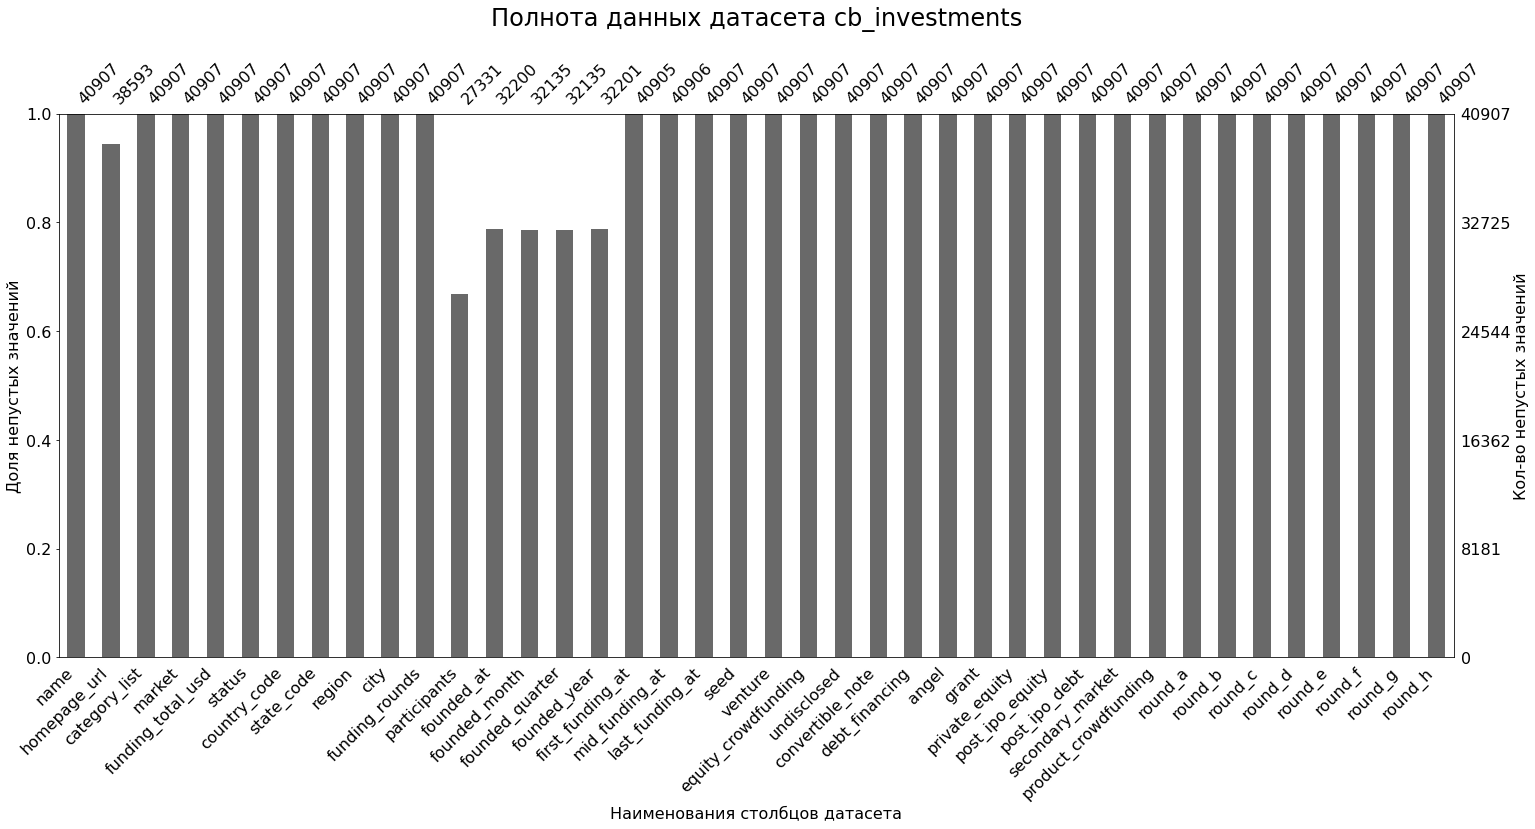

In [23]:
plt.figure(figsize=(20,10))

ax = msno.bar(cb_investments)
ax.set_title('Полнота данных датасета cb_investments\n', fontsize=24)
ax.set_xlabel('Наименования столбцов датасета', fontsize=16)
ax.set_ylabel('Доля непустых значений', fontsize=16)

ax2 = ax.twinx()
ax2.set_yticks([])
ax2.set_ylabel('Кол-во непустых значений',labelpad=60, fontsize=16)

plt.show()

На диаграмме видно, что после проведенных этапов обработки большая часть столбцов не имеет пропусков.

Оставшиеся пропуски визуализируются в столбцах `homepage_url`, `participants`, `founded_at`, `founded_month`, `founded_quarter`, `founded_year`, `first_funding_at`, `mid_funding_at`.

Выведу матрицу распределения пропусков в данных, чтобы увидеть расположение пропусков:

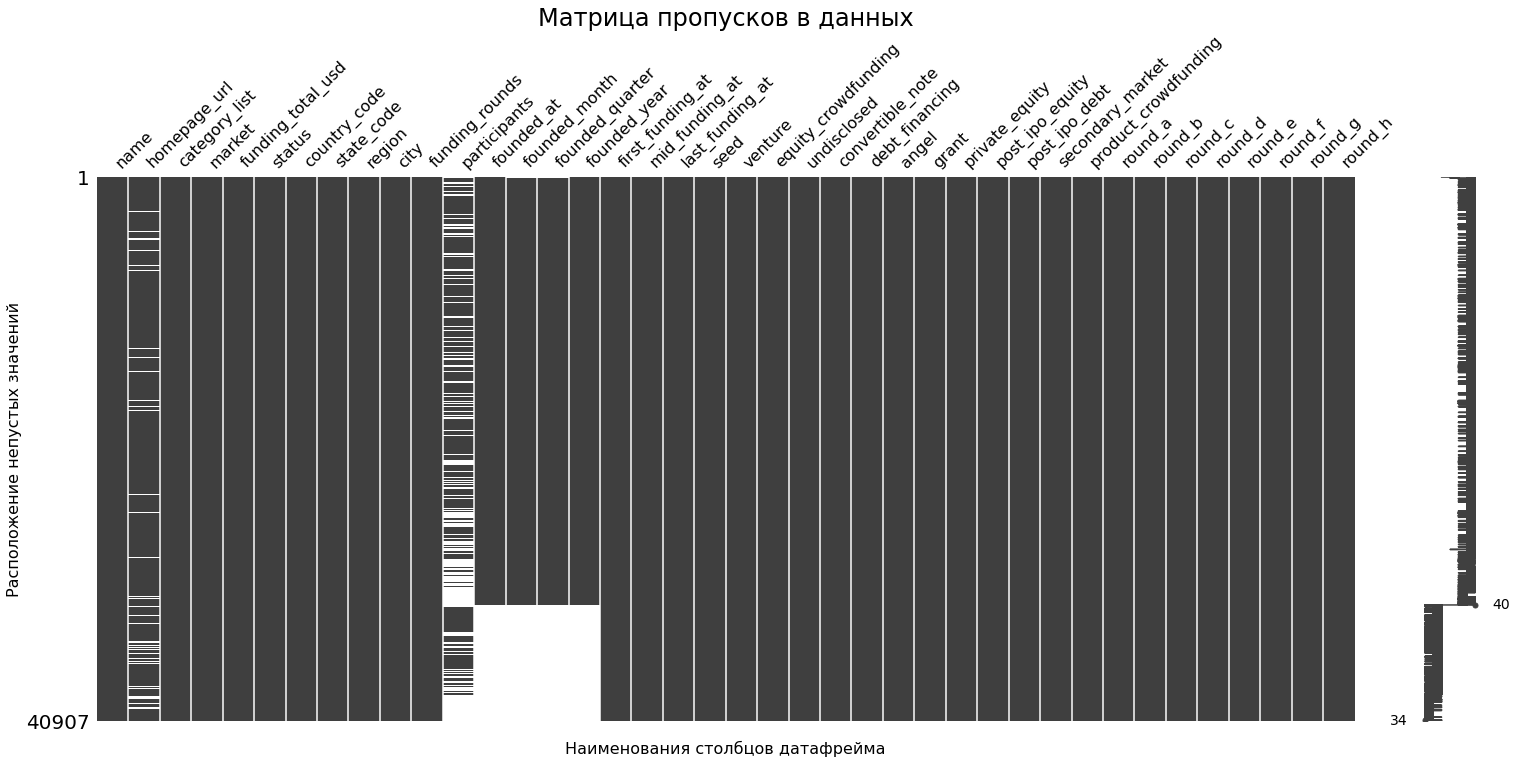

In [24]:
ax = msno.matrix(cb_investments)

ax.set_title('Матрица пропусков в данных', fontsize=24)
ax.set_xlabel('Наименования столбцов датафрейма', labelpad=20, fontsize=16)
ax.set_ylabel('Расположение непустых значений', fontsize=16)

plt.show()

По матрице сразу видно, что значения в столбцах `founded_at`, `founded_month`, `founded_quarter`, `founded_year` появляются одновременно, что дает основания предполагать, что они связаны - если не указано значение в столбце `founded_at`, то и в остальных столбцах не будет данных.

В столбцах `homepage_url` и `participants` встречаются рандомно.

Проверю корреляцию между пропусками:

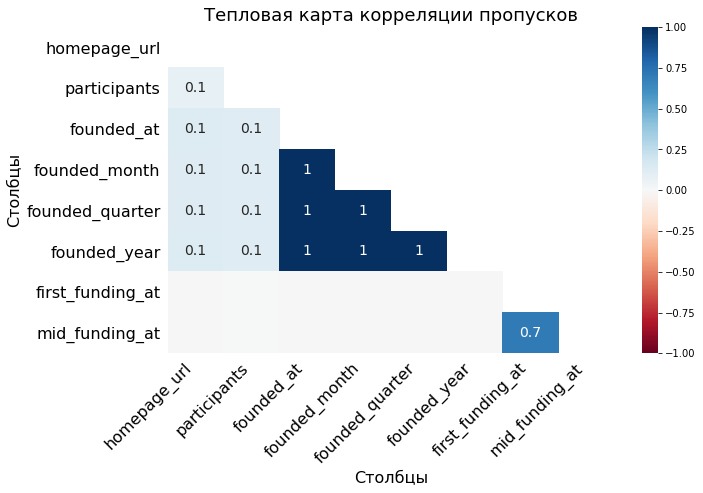

In [25]:
ax = msno.heatmap(cb_investments, figsize=(10, 6))

ax.set_title('Тепловая карта корреляции пропусков', fontsize=18)
ax.set_xlabel('Столбцы', fontsize=16)
ax.set_ylabel('Столбцы', fontsize=16)

plt.show()

Тепловая карта подтверждает корреляцию между столбцами `founded_at`, `founded_month`, `founded_quarter`, `founded_year` - если пропущено значение в `founded_at`, то по цепочке будут пропущены все остальные значения перечисленных столбцов.

Также видна корреляция 0.7 между столбцами `first_funding_at` и `mid_funding_at` - так же, как и со столбцами выше, если пропущено значение первого финансирования, то и значения среднего финансирования не будет.

Между остальными столбцами наблюдается корреляция 0.1, что говорит о практически отсутствующей зависимости межу пропусками в данных столбцах. 

Удалю пропуски в столбцах `first_funding_at` и `mid_funding_at`, так как данные из этих столбцов понадобятся в последующем анализе, а количество пропусков ничтожно мало:

In [26]:
cb_investments = cb_investments.dropna(subset=['first_funding_at','mid_funding_at'])

**Таким образом,**

- пропуски в столбцах `founded_at`, `founded_month`, `founded_quarter`, `founded_year` относятся к категории **MAR** и зависят друг от друга. Строки с пропусками в этих столбцах не были удалены так как данные из этих столбцов не будут использованы в анализе, а данные из других столбцов для этих строк лучше оставить.
- пропуски в столбцах `first_funding_at и mid_funding_at` так же относятся к категории **MAR** и были удалены, так как строк с пропусками в этих столбцах ничтожное количество в масштабе датасета.
- пропуски в столбцах `homepage_url` и `participants` не коррелируют с другими пропусками, поэтому относятся к категории **MCAR**. Данные пропуски не были удалены из датасета.

In [27]:
print('Количество строк датасета cb_investments после предобработки:', len(cb_investments))
print('Количество строк датасета cb_returns после предобработки:', len(cb_returns))
print('Количество столбцов в обоих датасетах без изменений')

Количество строк датасета cb_investments после предобработки: 40905
Количество строк датасета cb_returns после предобработки: 15
Количество столбцов в обоих датасетах без изменений


**В рамках предобработки данных проведены следующие операции:**
- наименования столбцов приведены к нижнему регистру, удалены лишние пробелы;
- значения в столбце `funding_total_usd` были приведены к числовому типу, удалены обозначения разрядности значений;
- столбцы, содержащие информацию о дате, были приведены к типу datetime;
- столбцы, содержащие текст, были приведены к нижнему регистру (столбцы с кодами стран, штатов приведены к верхнему регистру), удалены лишние пробелы;
- удалены 4855 явных дубликатов данных;
- удалены строки, полностью состоящие из пропусков;
- удалены строки, где пропущены значения `funding_total_usd`;
- заменены пропуски в столбце `mid_funding_at` на значение, равное середине интервала между `first_funding_at` и `last_funding_at`;
- в датасете `cb_returns` столбец с годом установлен как индекс датасета.

В процессе предобработки из датасета `cb_investments` исключено 24.66% строк. После предобработки данных датасет `cb_investments` состоит из 40905 строк и 40 столбцов, датасет `cb_returns` состоит из 15 строк и 14 столбцов. 

## Инжиниринг признаков

### Группы по срокам финансирования

Создам функцию, присваивающую категории по срокам финансирования, и добавлю эти значения в новый столбец `funding_category`:

In [28]:
def funding_category(row):
    funding_start = row['first_funding_at']
    funding_end = row['last_funding_at']
    days_between = (funding_end - funding_start).days
    if funding_start == funding_end:
        return 'единичное финансирование'
    elif days_between <= 365:
        return 'срок финансирования до года'
    return 'срок финансирования более года'

In [29]:
cb_investments['funding_category'] = cb_investments.apply(funding_category, axis=1)

In [30]:
categories = cb_investments['funding_category'].value_counts().to_frame().reset_index()
categories.columns = ['Категория','Кол-во']
categories['Доля'] = round((categories['Кол-во'] / categories['Кол-во'].sum()),4)

print('Количество компаний по срокам финансирования:\n')
display(categories)

Количество компаний по срокам финансирования:



,Категория,Кол-во,Доля
0,единичное финансирование,24289,0.5938
1,срок финансирования более года,12291,0.3005
2,срок финансирования до года,4325,0.1057


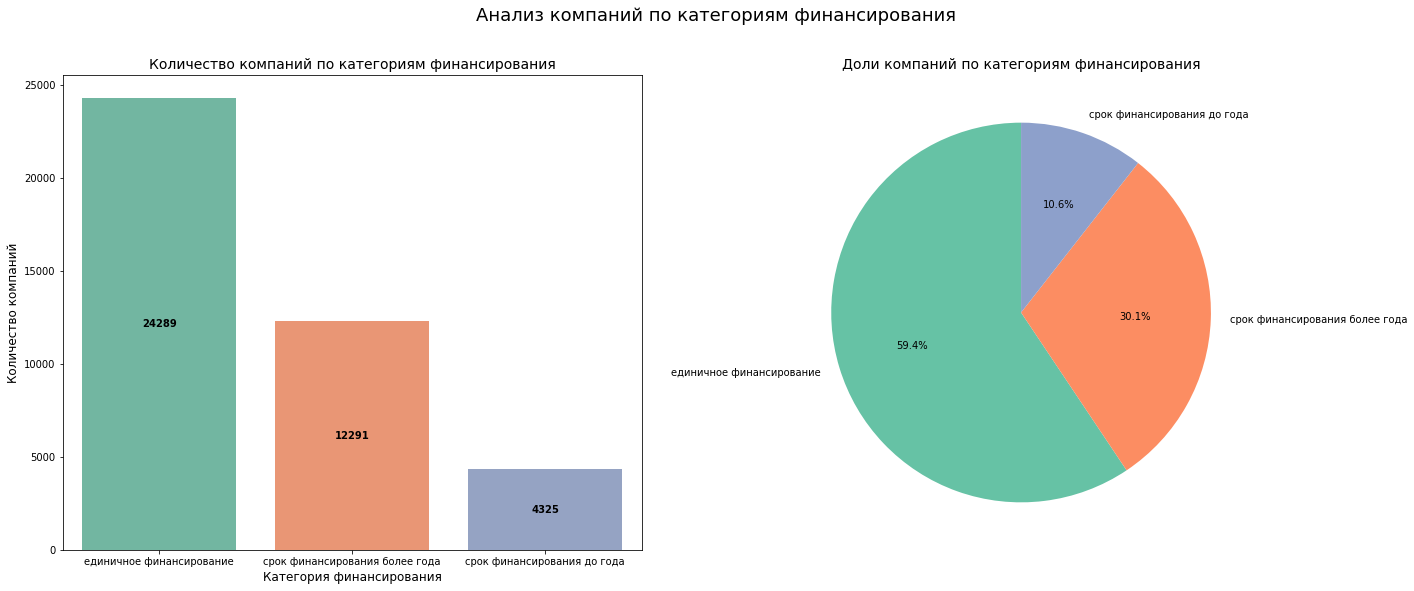

In [31]:
order = cb_investments['funding_category'].value_counts().index
colors = sns.color_palette('Set2', len(order))
color_map = dict(zip(order, colors))

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.countplot(x='funding_category', data=cb_investments, ax=axes[0], order=order, palette=color_map)

axes[0].set_title(f'Количество компаний по категориям финансирования', fontsize=14)
axes[0].set_xlabel('Категория финансирования', fontsize=12)
axes[0].set_ylabel('Количество компаний', fontsize=12)

for patch in axes[0].patches:
    height = patch.get_height().astype('int')
    y = height / 2
    x = patch.get_x() + patch.get_width() / 2
    axes[0].text(
        x, 
        y,
        height,
        ha='center',
        va='center',
        color='black',
        fontsize=10,
        fontweight='bold'
    )

cat_values = categories.set_index('Категория').loc[order]['Доля']
axes[1].pie(cat_values, labels=order, autopct='%1.1f%%', startangle=90, colors=[color_map[c] for c in order])
axes[1].set_title(f'Доли компаний по категориям финансирования', fontsize=14)

plt.suptitle(f'Анализ компаний по категориям финансирования', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

**Промежуточный вывод:**

Более половины компаний (59.4%) получали единичное финансирование, чуть меньше трети компаний (30.1%) получали последнее финансирования спустя больше года после первого финансирования. У оставшихся 10.6% компаний между первым и последним финансированием прошло менее года.

In [32]:
investments_cat = cb_investments.groupby('funding_category')['funding_total_usd'].sum().to_frame().reset_index()
investments_cat.columns = ['Категория', 'Объем средств, млрд']
investments_cat['Доля средств'] = round((investments_cat['Объем средств, млрд'] / investments_cat['Объем средств, млрд'].sum()),4)
investments_cat['Объем средств, млрд'] = investments_cat['Объем средств, млрд'] / 1e9
investments_cat

,Категория,"Объем средств, млрд",Доля средств
0,единичное финансирование,201.322403,0.3093
1,срок финансирования более года,402.708998,0.6187
2,срок финансирования до года,46.868002,0.0720


In [33]:
investments = categories.merge(investments_cat, how='inner', on='Категория')
investments

,Категория,Кол-во,Доля,"Объем средств, млрд",Доля средств
0,единичное финансирование,24289,0.5938,201.322403,0.3093
1,срок финансирования более года,12291,0.3005,402.708998,0.6187
2,срок финансирования до года,4325,0.1057,46.868002,0.0720


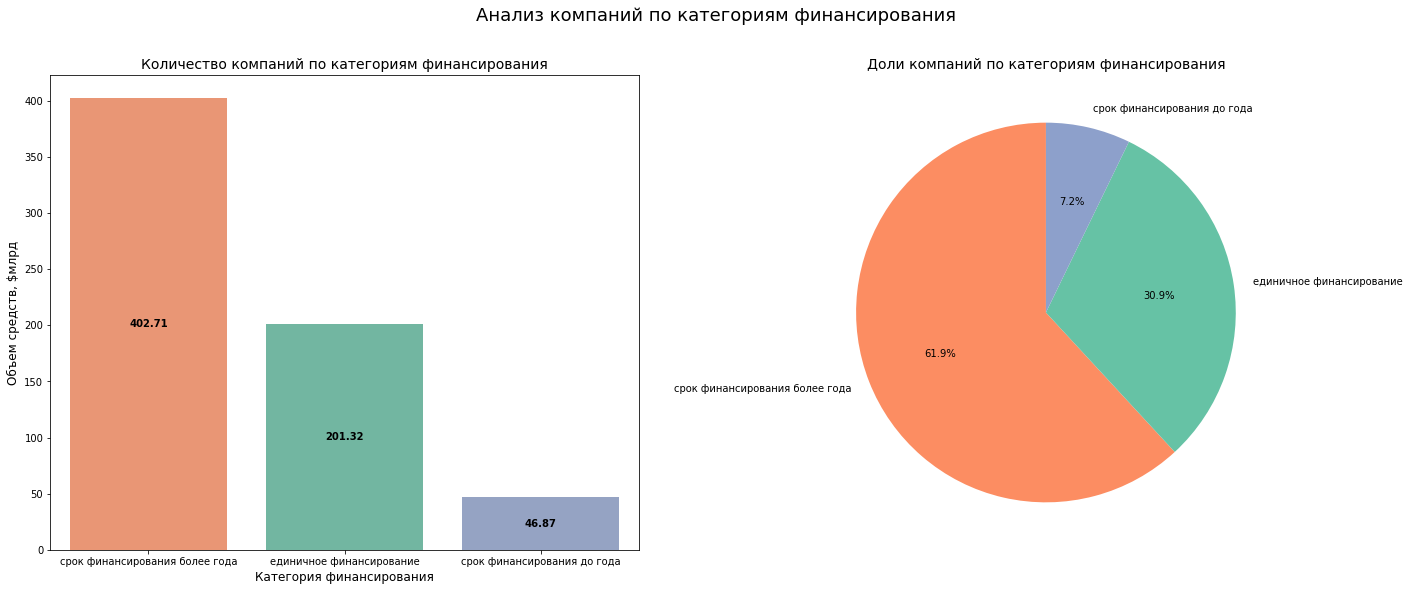

In [34]:
order = cb_investments.groupby('funding_category')['funding_total_usd'].sum().sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.barplot(x='Категория', y='Объем средств, млрд',data=investments, ax=axes[0], order=order, palette=color_map)

axes[0].set_title(f'Количество компаний по категориям финансирования', fontsize=14)
axes[0].set_xlabel('Категория финансирования', fontsize=12)
axes[0].set_ylabel('Объем средств, $млрд', fontsize=12)

for patch in axes[0].patches:
    height = patch.get_height().astype('float')
    y = height / 2
    x = patch.get_x() + patch.get_width() / 2 
    axes[0].text(
        x,
        y, 
        f'{height:.2f}',
        ha='center', 
        va='center', 
        color='black',
        fontsize=10,
        fontweight='bold'
    )

cat_values = investments.set_index('Категория').loc[order]['Доля средств']
axes[1].pie(cat_values, labels=order, autopct='%1.1f%%', startangle=90, colors=[color_map[c] for c in order])
axes[1].set_title(f'Доли компаний по категориям финансирования', fontsize=14)

plt.suptitle(f'Анализ компаний по категориям финансирования', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

**Промежуточный вывод:**

Несмотря на то, что большая часть компаний получали единичное финансирование, основной объем средств (61.9%) приходится на компании, у которых срок финансирования составляет более года. Чуть меньше трети от объема всех средств (30.9%) получали компании с единичным финансированием, а остаток (7.2%) приходится на компании, у которых срок финансирования до года.

Рынок характеризуется высокой долей единоразовых инвестиций, однако больше половины всех средств сосредоточено у компаний с длительным сроком финансирования. Можно предположить, что большая часть денег инвестируется преимущественно в более зрелые или стратегически перспективные компании, а единичное финансирование относится к недавно вышедшим на рынок компаниям, доходность которых еще не понятна.

### Выделение средних и нишевых сегментов рынка

Сегменты, к которым относится более 120 компаний, относятся к массовым, сегменты, в которые входит от 35 до 120 включительно, относятся к средним, а сегменты до 35 компаний - к нишевым. 

In [35]:
market_count = cb_investments['market'].value_counts()

In [36]:
def segment_category(row):
    if 120 < market_count[row['market']]:
        return 'массовый'
    elif 35 <= market_count[row['market']] <= 120:
        return 'средний'
    elif market_count[row['market']] < 35:
        return 'нишевый'
    return 'нет данных'

In [37]:
cb_investments['segment_category'] = cb_investments.apply(segment_category, axis=1)

In [38]:
segments = cb_investments.groupby('segment_category')['market'].nunique().to_frame()
segments['Компании'] = cb_investments['segment_category'].value_counts()
segments = segments.reset_index()
segments.columns = ['Сегмент','Рынки','Компании']
segments['Компании, доля'] = round(segments['Компании'] / segments['Компании'].sum(), 4)
segments['Рынки, доля'] = round(segments['Рынки'] / segments['Рынки'].sum(), 4)
segments

,Сегмент,Рынки,Компании,"Компании, доля","Рынки, доля"
0,массовый,49,36236,0.8859,0.1241
1,нишевый,289,830,0.0203,0.7316
2,средний,57,3839,0.0939,0.1443


----

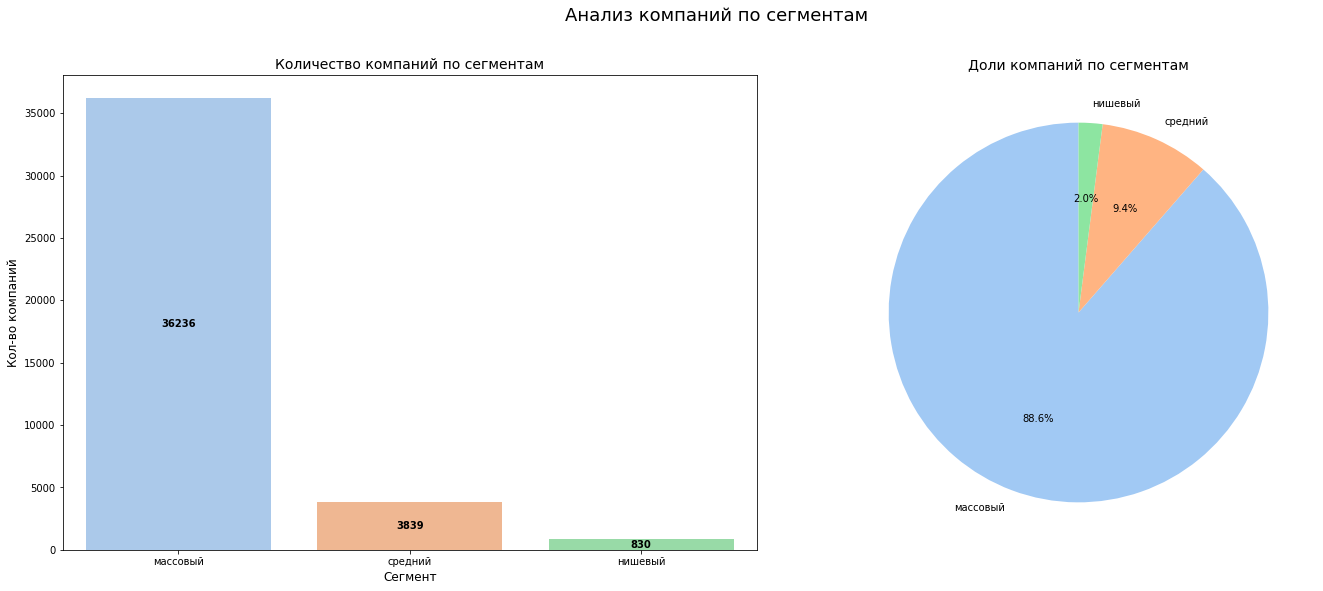

In [39]:
order = cb_investments.groupby('segment_category')['market'].nunique().sort_values(ascending=True).index
colors = sns.color_palette('pastel', len(order))
color_map = dict(zip(order, colors))

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.barplot(x='Сегмент', y='Компании',data=segments, ax=axes[0], palette=color_map, order=order)

axes[0].set_title(f'Количество компаний по сегментам', fontsize=14)
axes[0].set_xlabel('Сегмент', fontsize=12)
axes[0].set_ylabel('Кол-во компаний', fontsize=12)

for patch in axes[0].patches:
    height = patch.get_height().astype('int')
    y = height / 2
    x = patch.get_x() + patch.get_width() / 2
    axes[0].text(
        x,
        y,
        height,
        ha='center',
        va='center',
        color='black',
        fontsize=10,
        fontweight='bold'
    )
    
segs_values = segments.set_index('Сегмент').loc[order]['Компании, доля']   
axes[1].pie(segs_values, labels=order, autopct='%1.1f%%', startangle=90, colors=[color_map[c] for c in order])
axes[1].set_title(f'Доли компаний по сегментам', fontsize=14)

plt.suptitle(f'Анализ компаний по сегментам', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

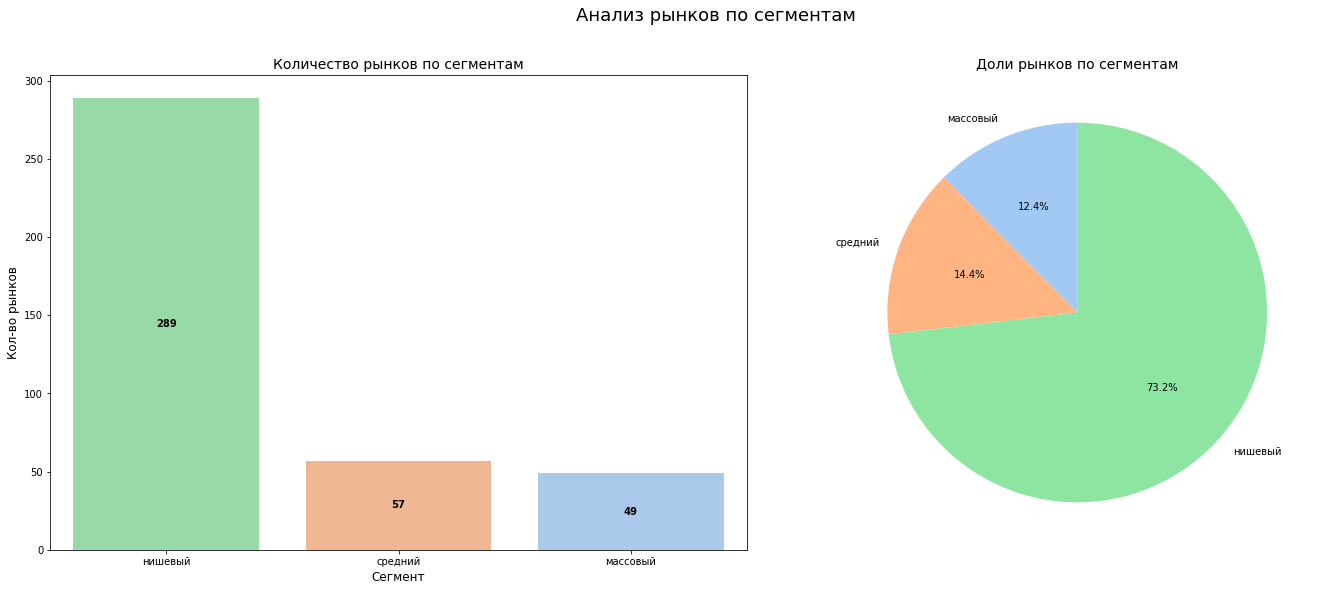

In [40]:
order2 = order[::-1]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.barplot(x='Сегмент', y='Рынки',data=segments, ax=axes[0], palette=color_map, order=order2)

axes[0].set_title(f'Количество рынков по сегментам', fontsize=14)
axes[0].set_xlabel('Сегмент', fontsize=12)
axes[0].set_ylabel('Кол-во рынков', fontsize=12)

for patch in axes[0].patches:
    height = patch.get_height().astype('int')
    y = height / 2
    x = patch.get_x() + patch.get_width() / 2
    axes[0].text(
        x,
        y,
        height,
        ha='center',
        va='center',
        color='black',
        fontsize=10,
        fontweight='bold'
    )
    
segs_values = segments.set_index('Сегмент').loc[order]['Рынки, доля']   
axes[1].pie(segs_values, labels=order, autopct='%1.1f%%', startangle=90, colors=[color_map[c] for c in order])
axes[1].set_title(f'Доли рынков по сегментам', fontsize=14)

plt.suptitle(f'Анализ рынков по сегментам', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

**Промежуточный вывод:**

Несмотря на то, что к массовому сегменту рынков относится наибольшее количество компаний (36236), самих рынков в разрезе сегмента выделено наименьшее количество. У нишевого сегмента ситуация обратно пропорциональная - при небольшом количестве компаний этот сегмент самый разнообразный по количеству направлений (830 компаний на 239 рынках).

Это может говорить о том, что в массовом сегменте большая конкуренция в рамках одного рынка, а вот в нишевом сегменте рынки достаточно узкие, представленные малым количеством компаний.

----

Оставляю в столбце `market` только массовые сегменты. Для остальных сегментов заменяю значения на заглушки — `niche` для нишевых и `mid` для средних.

In [41]:
def market_fill(row):
    if row['segment_category'] == 'нишевый':
        return 'niche'
    elif row['segment_category'] == 'средний':
        return 'mid'
    return row['market']

In [42]:
cb_investments['market'] = cb_investments.apply(market_fill, axis=1)

**Промежуточный вывод:**

На данном этапе были выделены три сегмента рынка по количеству компаний, входящих в ту или иную отрасль. Отрасли с более 120 компаниями отнесены к массовому сегменту, с менее 35 компаний - к нишевому сегменту, остальные - к среднему. 

Большая часть отраслей относится к нишевому сегменту (289 отраслей включающих 830 компаний), далее идет средний сегмент (57 отраслей включающих 3839 компаний) и массовый (49 отраслей включающих 36236 компаний). В нишевом сегмете большинство отраслей включают 1-2 компании, явное правоассимметриченое распределение значений. В среднем сегменте распределение отраслей по количеству компаний более равномерное.

## Работа с выбросами и анализ

### Анализ выбросов в каждом из сегментов

**Описание данных о финансировании компаний**

In [43]:
cb_investments['funding_total_usd'].describe(percentiles=[0.01,0.1,0.25,0.5,0.75,0.9,0.99]).apply(lambda x: format(x, '.0f'))

count          40905
mean        15912466
std        168682924
min                1
1%             10000
10%            59544
25%           350000
50%          2000000
75%         10000000
90%         31540739
99%        200000000
max      30079503000
Name: funding_total_usd, dtype: object

В общем описании данных столбца `funding_total_usd` явно выделяются минимальное и максимальное значение, которые значительно отличаются от 1 и 99 перцентилей соответственно. 

Стандартное отклонение высокое, что говорит о большом разбросе данных об объемах финансирования. Среднее также значительно больше медианного значения из-за высоких значений.

Проверю компании с минимальным и максимальным объемом финансирования:

In [44]:
cb_investments[cb_investments['funding_total_usd'] == 1]

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h,funding_category,segment_category
48817,deck works.co,http://deckworks.co,|venture capital|design|startups|,design,1.0,operating,nan,nan,nan,nan,1.0,NaN,NaT,NaN,NaN,NaN,2014-08-19,2014-08-19,2014-08-19,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,единичное финансирование,массовый


In [45]:
cb_investments[cb_investments['funding_total_usd'] == 30079503000]

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h,funding_category,segment_category
623,verizon communications,http://www.verizon.com/?lid=//global//residential,|mobile|,mobile,3.007950e+10,operating,usa,ny,new york city,new york,5.0,NaN,1983-10-07,1983-10,1983-Q4,1983.0,2010-01-26,2012-02-12,2014-02-28,0.0,0.0,0.0,0.0,0.0,3.007950e+10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,срок финансирования более года,массовый


Минимальное и максимальное значения явно можно счесть выбросами, так как они сильно отличаются от 1 и 99 перцентилей и исказят картину распределения. Значение финансирования в 1 доллар может быть как технической ошибкой ввода, так и заполнением неизвестного значения. 

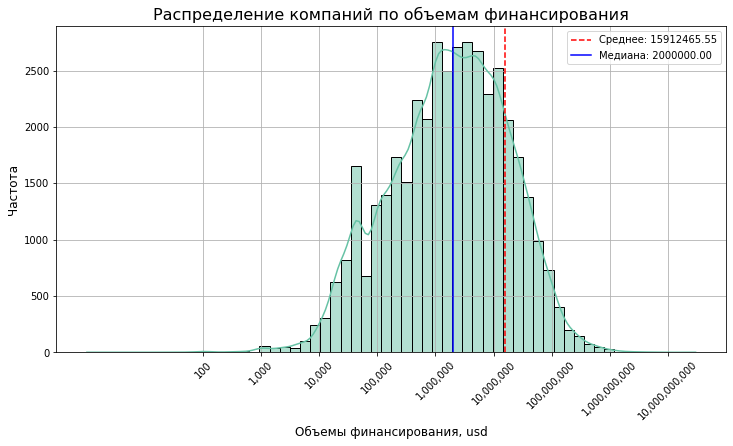

In [46]:
plt.figure(figsize=(12,6))
sns.histplot(
    data=cb_investments,
    x='funding_total_usd',
    log_scale=True,
    bins=60,
    color='#66c2a5',
    kde=True
)

mean_val = cb_investments['funding_total_usd'].mean()
median_val = cb_investments['funding_total_usd'].median()

plt.axvline(mean_val, color='red', linestyle='--', label=f'Среднее: {mean_val:.2f}')
plt.axvline(median_val, color='blue', linestyle='-', label=f'Медиана: {median_val:.2f}')

ticks = [1e2, 1e3, 1e4, 1e5, 1e6, 1e7, 1e8, 1e9, 1e10]

plt.xscale('log')
plt.xticks(ticks, [f'{int(t):,}' for t in ticks], rotation=45)
plt.title('Распределение компаний по объемам финансирования', fontsize=16)
plt.xlabel('Объемы финансирования, usd', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.legend()
plt.grid()
plt.show()

Построю диаграмму размаха без выбросов, чтобы оценить размах Q1-Q3 и распределение основной массы значений:

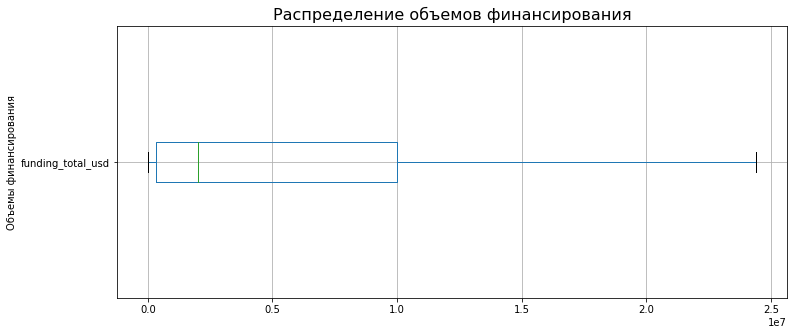

In [47]:
boxplot = cb_investments.boxplot(column='funding_total_usd', vert=False, figsize=(12, 5), showfliers= False)

boxplot.set_title('Распределение объемов финансирования', fontsize=16)
boxplot.set_ylabel('Объемы финансирования')

plt.show()

**Промежуточный вывод:**

На диаграмме размаха явно визуализируется правоассимметричное распределение значений. Основная часть значений объема финансирования - до 25.000.000 долларов. Медианное значение смещено влево в "ящике", что говорит о том что большая часть объемов финансирования находятся около отметки в 2.000.000 долларов.

На основании визуальной оценки можно сказать, что типичным объемом финансирования для компаний является сумма до USD 25.000.000. Большая часть значений финансирования находится в диапазоне от USD 350.000 до USD 10.000.000.

--------

**Компании и сегменты рынка с аномальными объемами финансирования**

Выведу числовые показатели по объемам финансирования в разрезе рынков и посчитаю IQR и пороги выбросов:

*Коэффициент для расчета порогов выбросов IQR увеличу до 2 для того, чтобы не считать аномалиями значения большого финансирования - они вполне реальны для крупных компаний.*

In [48]:
lim_investments_segs = cb_investments.groupby('market')['funding_total_usd'].describe().sort_values(by='max',ascending=False).reset_index()


lim_investments_segs['IQR'] = lim_investments_segs['75%'] - lim_investments_segs['25%']

#минимальный порог выбросов устанавливаю равным 1 перцентилю в разрезе рынка
lim_investments_segs['min_limit'] = lim_investments_segs['market'].map(cb_investments.groupby('market')['funding_total_usd'].quantile(0.01))
lim_investments_segs['max_limit'] = lim_investments_segs['75%'] + 2 * lim_investments_segs['IQR'] 

lim_investments_segs.head(10)

,market,count,mean,std,min,25%,50%,75%,max,IQR,min_limit,max_limit
0,mobile,2344.0,2.374835e+07,6.220266e+08,291.0,300000.0,1700000.0,7694375.00,3.007950e+10,7394375.00,11671.50,22483125.00
1,finance,828.0,2.462914e+07,2.075769e+08,1000.0,500000.0,3119440.0,13454698.25,5.800000e+09,12954698.25,12000.00,39364094.75
2,internet,241.0,3.987556e+07,3.741739e+08,2500.0,250000.0,1110000.0,5000000.00,5.700000e+09,4750000.00,10000.00,14500000.00
3,nan,2503.0,1.021201e+07,1.272101e+08,14.0,54488.0,409299.0,2200000.00,5.162513e+09,2145512.00,5000.00,6491024.00
4,mid,3839.0,1.606748e+07,9.731435e+07,100.0,250000.0,1491477.0,7785050.00,3.500000e+09,7535050.00,9300.58,22855150.00
5,health and wellness,873.0,1.497493e+07,9.751957e+07,3750.0,323400.0,1750000.0,7750000.00,2.600000e+09,7426600.00,19892.20,22603200.00
6,social media,1003.0,7.913413e+06,7.968958e+07,1000.0,125000.0,673400.0,3000000.00,2.425700e+09,2875000.00,3510.00,8750000.00
7,biotechnology,3590.0,2.112054e+07,5.653151e+07,1000.0,1500000.0,5507500.0,22031670.50,2.400000e+09,20531670.50,30577.61,63095011.50
8,enterprise software,1381.0,1.669119e+07,7.038055e+07,5000.0,1000000.0,4500000.0,15000000.00,2.000000e+09,14000000.00,20000.00,43000000.00
9,manufacturing,596.0,1.612832e+07,7.110103e+07,4900.0,750000.0,3464999.0,13671551.00,1.567504e+09,12921551.00,19900.00,39514653.00


Добавлю лимиты в исходный датафрейм для дальнейшего сравнения:

In [49]:
cb_investments = cb_investments.merge(lim_investments_segs, how='left', on='market')

In [50]:
cb_investments['out_of_limits'] = (
    (cb_investments['funding_total_usd'] < cb_investments['min_limit']) |
    (cb_investments['funding_total_usd'] > cb_investments['max_limit'])
)

In [51]:
out_of_limits_companies = cb_investments[cb_investments['out_of_limits'] == True].sort_values(ascending=False, by='funding_total_usd')
out_of_limits_companies.head(10)

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h,funding_category,segment_category,count,mean,std,min,25%,50%,75%,max,IQR,min_limit,max_limit,out_of_limits
497,verizon communications,http://www.verizon.com/?lid=//global//residential,|mobile|,mobile,3.007950e+10,operating,usa,ny,new york city,new york,5.0,NaN,1983-10-07,1983-10,1983-Q4,1983.0,2010-01-26,2012-02-12 00:00:00,2014-02-28,0.0,0.000000e+00,0.0,0.0,0.0,3.007950e+10,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,срок финансирования более года,массовый,2344.0,2.374835e+07,6.220266e+08,291.0,300000.0,1700000.0,7694375.00,3.007950e+10,7394375.00,11671.50,22483125.00,True
40156,sberbank,http://www.sberbank.ru,|banking|finance|,finance,5.800000e+09,operating,rus,nan,moscow,moscow,1.0,NaN,NaT,NaN,NaN,NaN,2014-07-07,2014-07-07 00:00:00,2014-07-07,0.0,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,5.800000e+09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,единичное финансирование,массовый,828.0,2.462914e+07,2.075769e+08,1000.0,500000.0,3119440.0,13454698.25,5.800000e+09,12954698.25,12000.00,39364094.75,True
6119,clearwire,http://www.clearwire.com,|internet|mobile|,internet,5.700000e+09,acquired,usa,wa,seattle,kirkland,4.0,5.0,2003-10-01,2003-10,2003-Q4,2003.0,2008-05-06,2009-11-24 00:00:00,2013-02-27,0.0,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.0,0.0,8.000000e+07,4.700000e+09,9.200000e+08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,срок финансирования более года,массовый,241.0,3.987556e+07,3.741739e+08,2500.0,250000.0,1110000.0,5000000.00,5.700000e+09,4750000.00,10000.00,14500000.00,True
1145,charter communications,http://www.charter.com,nan,nan,5.162513e+09,operating,usa,ct,hartford,stamford,2.0,NaN,1993-01-01,1993-01,1993-Q1,1993.0,2009-11-21,2012-04-18 12:00:00,2014-09-15,0.0,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,1.662513e+09,3.500000e+09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,срок финансирования более года,массовый,2503.0,1.021201e+07,1.272101e+08,14.0,54488.0,409299.0,2200000.00,5.162513e+09,2145512.00,5000.00,6491024.00,True
252,first data corporation,http://www.firstdata.com,|trading|payments|,mid,3.500000e+09,operating,usa,ga,atlanta,atlanta,1.0,NaN,1971-01-01,1971-01,1971-Q1,1971.0,2014-07-03,2014-07-03 00:00:00,2014-07-03,0.0,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.0,0.0,3.500000e+09,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,единичное финансирование,средний,3839.0,1.606748e+07,9.731435e+07,100.0,250000.0,1491477.0,7785050.00,3.500000e+09,7535050.00,9300.58,22855150.00,True
39400,cofco,http://cofco.com,nan,nan,3.200000e+09,operating,chn,nan,chn - other,nan,1.0,NaN,NaT,NaN,NaN,NaN,2014-02-22,2014-02-22 00:00:00,2014-02-22,0.0,0.000000e+00,0.0,0.0,0.0,3.200000e+09,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,единичное финансирование,массовый,2503.0,1.021201e+07,1.272101e+08,14.0,54488.0,409299.0,2200000.00,5.162513e+09,2145512.00,5000.00,6491024.00,True
8048,sigmacare,http://sigmacare.com,|health and wellness|,health and wellness,2.600000e+09,operating,usa,ny,new york city,new york,1.0,1.0,2005-01-01,2005-01,2005-Q1,2005.0,2013-07-29,2013-07-29 00:00:00,2013-07-29,0.0,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.0,0.0,2.600000e+09,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,единичное финансирование,массовый,873.0,1.497493e+07,9.751957e+07,3750.0,323400.0,1750000.0,7750000.00,2.600000e+09,7426600.00,19892.20,22603200.00,True
7013,facebook,http

In [52]:
out_of_limits_segments = out_of_limits_companies['market'].value_counts().to_frame().reset_index()
out_of_limits_segments.columns = ['Рынок','Кол-во компаний']
out_of_limits_segments['Доля'] = round((out_of_limits_segments['Кол-во компаний'] / out_of_limits_segments['Кол-во компаний'].sum()),4)
out_of_limits_segments.head(10)

,Рынок,Кол-во компаний,Доля
0,mid,530,0.1094
1,software,529,0.1092
2,nan,350,0.0722
3,biotechnology,345,0.0712
4,mobile,280,0.0578
5,e-commerce,256,0.0528
6,curated web,196,0.0405
7,clean technology,145,0.0299
8,social media,134,0.0277
9,niche,126,0.0260


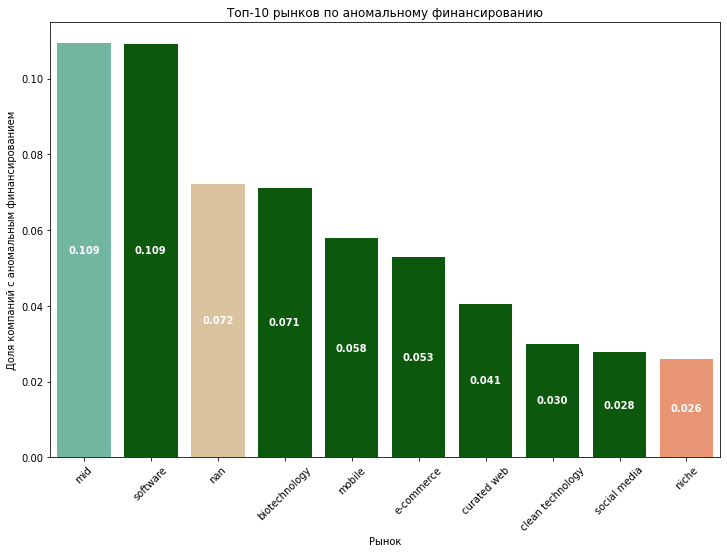

In [53]:
colors = out_of_limits_segments.head(10)['Рынок'].apply(
    lambda x: '#fc8d62' if x == 'niche' else ('#66c2a5' if x == 'mid' else ('#e5c494' if x == 'nan' else 'darkgreen'))
)

plt.figure(figsize=(12,8))

ax = sns.barplot(x='Рынок', y='Доля', data=out_of_limits_segments.head(10), palette=colors)

for patch in ax.patches:
    height = patch.get_height().astype('float')  #нахожу значение по оси y
    y = height / 2 #нахожу середину столбца по оси y
    x = patch.get_x() + patch.get_width() / 2  #нахожу середину столбца по оси x
    ax.text(
        x, #размещаю по центру горизонтально
        y, #размещаю по центру вертикально
        f'{height:.3f}',
        ha='center', #выравниваю
        va='center', #выравниваю
        color='white',
        fontsize=10,
        fontweight='bold'
    )

plt.xticks(rotation=45)
plt.ylabel('Доля компаний с аномальным финансированием')
plt.title('Топ-10 рынков по аномальному финансированию')
plt.show()

**Промежуточный вывод:**

На диаграмме видно, что в среднем сегменте рынков больше всего компаний, имеющих аномальное финансирование - почти 11%. Нишевый сегмент рынков закрывает топ-10 по аномальному финансированию с долей таких компаний в 2.6%. Из компаний массового сегмента наибольшая доля аномальных финансирований приходится на рынок `software`. Также можно отметить, что среди компаний, для которых не указан рынок, доля компаний с аномальным финансированием также высока и составляет 7.2%.

### Опредение границы рассматриваемого периода, исключение аномалий

Проверьте по датасету, можно ли считать, что вам предоставили полные данные за 2014 год. Затем исключите из датасета компании, которые вы ранее посчитали получившими аномальное финансирование.

Когда исключите аномальные записи, на основе столбцов `mid_funding_at` и `funding_rounds` оставьте в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

**Проверка полноты данных за 2014 год**

In [54]:
invest_2014 = cb_investments[
    (cb_investments['first_funding_at'].dt.year == 2014) | 
    (cb_investments['mid_funding_at'].dt.year == 2014) |
    (cb_investments['last_funding_at'].dt.year == 2014)
].copy()

In [55]:
invest_2014['first_funding_month'] = invest_2014['first_funding_at'].dt.month
invest_2014['mid_funding_month'] = invest_2014['mid_funding_at'].dt.month
invest_2014['last_funding_month'] = invest_2014['last_funding_at'].dt.month

In [56]:
first_2014 = invest_2014[invest_2014['first_funding_at'].dt.year == 2014]
first_2014['first_funding_at'].agg(['min', 'max'])

min   2014-01-01
max   2014-12-31
Name: first_funding_at, dtype: datetime64[ns]

In [57]:
mid_2014 = invest_2014[invest_2014['mid_funding_at'].dt.year == 2014]
mid_2014['mid_funding_at'].agg(['min', 'max'])

min   2014-01-01
max   2014-12-31
Name: mid_funding_at, dtype: datetime64[ns]

In [58]:
last_2014 = invest_2014[invest_2014['last_funding_at'].dt.year == 2014]
last_2014['last_funding_at'].agg(['min', 'max'])

min   2014-01-01
max   2014-12-31
Name: last_funding_at, dtype: datetime64[ns]

In [59]:
invest_2014[['first_funding_month','mid_funding_month','last_funding_month']].agg(['min', 'max', 'nunique'])

,first_funding_month,mid_funding_month,last_funding_month
min,1,1,1
max,12,12,12
nunique,12,12,12


По агрегированным данным выше можно сделать вывод, что данные за 2014 год полные - в столбцах о месяцах финансирования есть данные за все 12 месяцев 2014 года.

----

**Фильтр компаний**

Исключаю компании, получившие аномальное финансирование, а также компании, получавшие финансирование в годы с 50 и менее раундов.

In [60]:
cb_investments = cb_investments[cb_investments['out_of_limits'] == False]

In [61]:
cb_investments['funding_year'] = cb_investments['mid_funding_at'].dt.year

In [62]:
fundings = cb_investments.groupby('funding_year')['funding_rounds'].sum().to_frame().sort_values(by='funding_year', ascending=False)

fundings = fundings[fundings['funding_rounds'] >= 50]

fundings

,funding_rounds
funding_year,
2014,7075.0
2013,12989.0
2012,9942.0
2011,7801.0
2010,6473.0
2009,4900.0
2008,3930.0
2007,3068.0
2006,1966.0


Начиная с 2000 года каждый следующий год имеет более 50 раундов финансирования, поэтому в датасете оставляю только эти годы:

In [63]:
cb_investments = cb_investments[cb_investments['funding_year'] >= 1999]

**Промежуточный вывод:**

На данном этапе была произведена проверка полноты данных за 2014 год - в датасете содержатся данные за все 12 месяцев года, поэтому их можно считать полными. 

Из датасета были исключены компании, имеющие аномальное финансирование, границы которого были определены на предыдущем этапе (минимальный порог - USD 10.000, соотвествующий 1 перцентилю, а максимальный порог - 75 перцентиль с коэффициентом 4хIQR в разрезе сегмента рынка).

Выделены и оставлены в датасете данные за 2000-2014 год - в эти годы количество раундов финансирования составляло 50 и более. 

### Анализ типов финансирования по объёму и популярности

**Суммы общих привлеченных инвестиций по типам финансирования**

In [64]:
cols = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note',
    'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity',
    'post_ipo_debt', 'secondary_market', 'product_crowdfunding'
]

cb_investments[cols] = cb_investments[cols].apply(pd.to_numeric, errors='coerce')

funding_types = cb_investments[cols].sum().to_frame().reset_index()
funding_types.columns = ['Тип финансирования','Сумма, млн']
funding_types['Сумма, млн'] = funding_types['Сумма, млн'] / 1000000
funding_types

,Тип финансирования,"Сумма, млн"
0,seed,9653.310662
1,venture,148329.759682
2,equity_crowdfunding,244.811185
3,undisclosed,2459.092199
4,convertible_note,611.990749
5,debt_financing,9514.653669
6,angel,2552.697785
7,grant,2129.357908
8,private_equity,6038.165307
9,post_ipo_equity,2464.225628


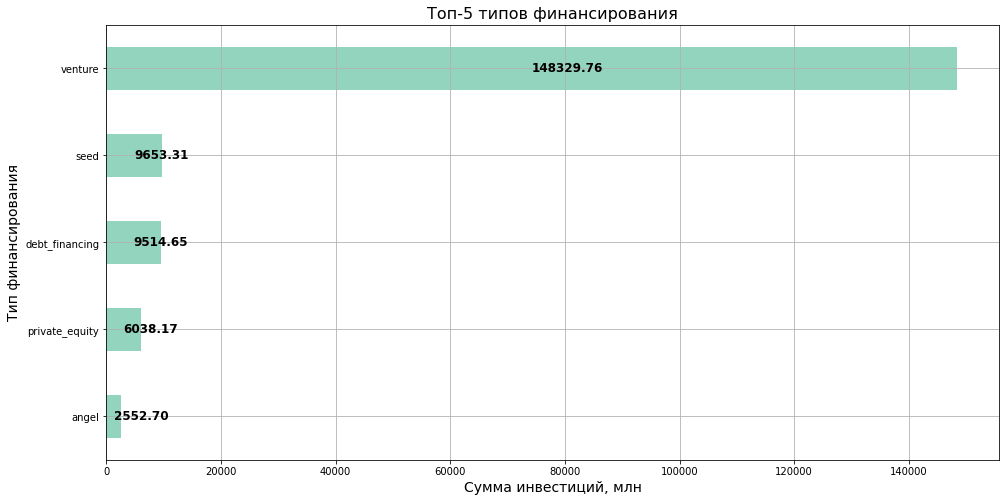

In [65]:
top_funding_types = funding_types.sort_values(by='Сумма, млн').tail(5)

ax = top_funding_types.plot(
    kind='barh',
    x='Тип финансирования', 
    y='Сумма, млн', 
    color='#66c2a5', 
    alpha=0.7, 
    legend=False,
    figsize=(16,8)
)

for patch in ax.patches:
    width = patch.get_width().astype('float64') 
    y = patch.get_y() + patch.get_height() / 2 
    ax.text(
        width * 0.5, 
        y, 
        f'{width:.2f}',
        ha='left', 
        va='center', 
        color='black',
        fontsize=12,
        fontweight='bold'
    )
plt.xlabel('Сумма инвестиций, млн', fontsize=14)
plt.ylabel('Тип финансирования', fontsize=14)
plt.title('Топ-5 типов финансирования', fontsize=16)
plt.grid()

plt.show()

**Промежуточный вывод:**

Венчурные инвестиции являются самым большим типом финансирования с точки зрения объемов привлеченных денег с большим отрывом от других - венчурное инвестирование привлекло более 204 млрд долларов. Также в топ-5 типов финансирования являются долговое финансирование (более 13 млрд долларов), прямые вложения (более 12 млрд долларов), финансирование на посевной стадии (более 10 млрд долларов) и финансирование после IPO (более 4 млрд долларов).

----

**Частота типов финансирования**

In [66]:
cols = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note',
    'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity',
    'post_ipo_debt', 'secondary_market', 'product_crowdfunding'
]
popular_funding_types = (cb_investments[cols] != 0).sum().to_frame().reset_index()
popular_funding_types.columns = ['Тип финансирования','Кол-во событий']
popular_funding_types.sort_values(by='Кол-во событий', ascending=False)

,Тип финансирования,Кол-во событий
1,venture,19515
0,seed,13287
5,debt_financing,3372
6,angel,2959
7,grant,998
3,undisclosed,840
8,private_equity,683
4,convertible_note,515
2,equity_crowdfunding,446
12,product_crowdfunding,202


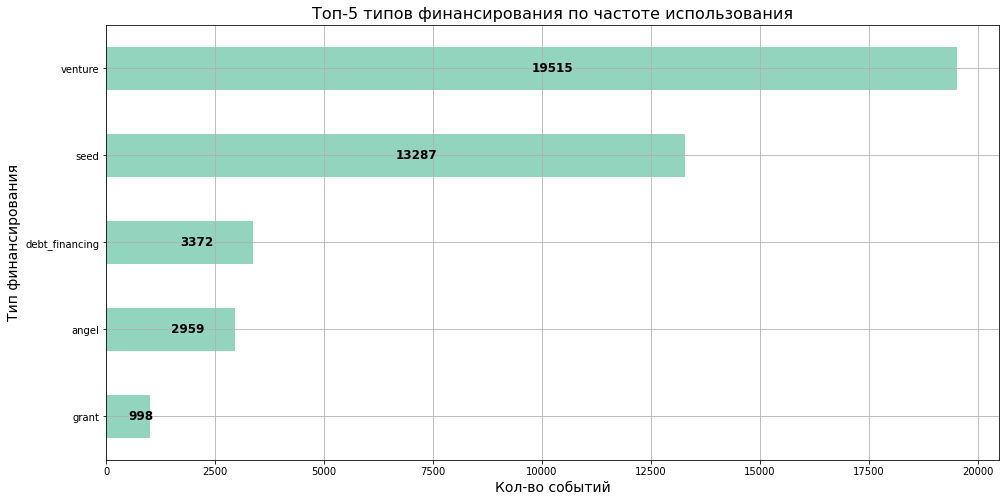

In [67]:
popular5_funding_types = popular_funding_types.sort_values(by='Кол-во событий').tail(5)

ax = popular5_funding_types.plot(
    kind='barh',
    x='Тип финансирования', 
    y='Кол-во событий', 
    color='#66c2a5', 
    alpha=0.7, 
    legend=False,
    figsize=(16,8)
)

for patch in ax.patches:
    width = patch.get_width().astype('int')
    y = patch.get_y() + patch.get_height() / 2 
    ax.text(
        width * 0.5,
        y,
        width,
        ha='left',
        va='center', 
        color='black',
        fontsize=12,
        fontweight='bold'
    )
plt.xlabel('Кол-во событий', fontsize=14)
plt.ylabel('Тип финансирования', fontsize=14)
plt.title('Топ-5 типов финансирования по частоте использования', fontsize=16)
plt.grid()

plt.show()

**Промежуточный вывод:**

По частоте событий венчурное инвестирование также является самым популярным - этот тип инвестиций встречается в датасете 21171 раз. Наиболее часто встречающимися типами инвестирования являются также инвестиции на посевной стадии (13482 раза), долговое финансирования (3688 раз), инвестиции от бизнес-ангелов (3021 раз) и гранты (1039 раз).

----

**Сравнение типов финансирования по объемам и частоте**

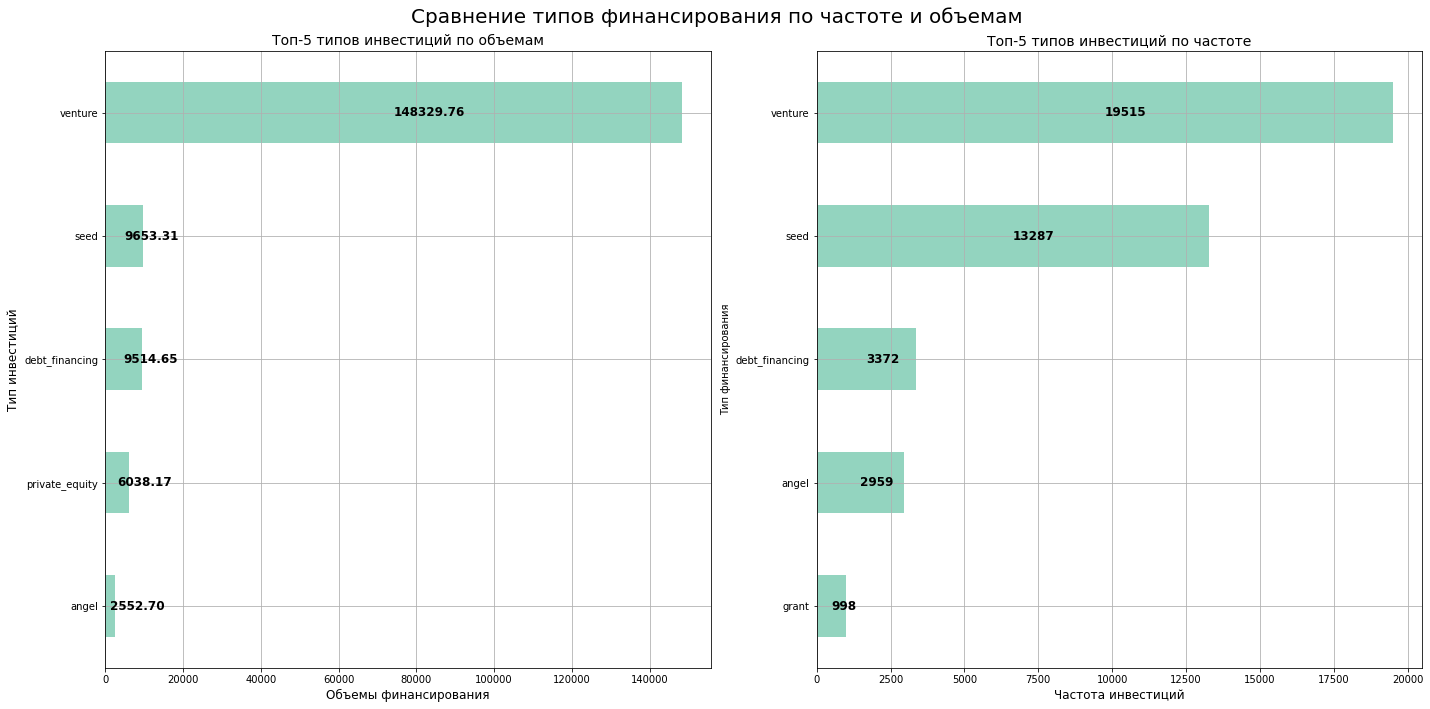

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

top_funding_types = funding_types.sort_values(by='Сумма, млн').tail(5)
popular5_funding_types = popular_funding_types.sort_values(by='Кол-во событий').tail(5)

top_funding_types.plot(
    kind='barh',
    x='Тип финансирования', 
    y='Сумма, млн', 
    color='#66c2a5', 
    alpha=0.7, 
    legend=False,
    ax=axes[0]
)

for patch in axes[0].patches:
    width = patch.get_width().astype('float64')
    y = patch.get_y() + patch.get_height() / 2 
    axes[0].text(
        width * 0.5, 
        y, 
        f'{width:.2f}',
        ha='left', 
        va='center', 
        color='black',
        fontsize=12,
        fontweight='bold'
    )

axes[0].set_title(f'Топ-5 типов инвестиций по объемам', fontsize=14)
axes[0].set_xlabel('Объемы финансирования', fontsize=12)
axes[0].set_ylabel('Тип инвестиций', fontsize=12)
axes[0].grid()

axes[1] = popular5_funding_types.plot(
    kind='barh',
    x='Тип финансирования', 
    y='Кол-во событий', 
    color='#66c2a5', 
    alpha=0.7, 
    legend=False,
    ax=axes[1]
)

for patch in axes[1].patches:
    width = patch.get_width().astype('int')
    y = patch.get_y() + patch.get_height() / 2 
    axes[1].text( 
        width * 0.5,
        y, 
        width,
        ha='left', 
        va='center', 
        color='black',
        fontsize=12,
        fontweight='bold'
    )
axes[1].set_title(f'Топ-5 типов инвестиций по частоте', fontsize=14)
axes[1].set_xlabel('Частота инвестиций', fontsize=12)
axes[1].grid()

plt.suptitle('Сравнение типов финансирования по частоте и объемам', fontsize=20)
plt.tight_layout()
plt.show()

**Промежуточный вывод:**

При сравнении популярных типов финансирования заметно выделяется *венчурное инвестирование* - он является наиболее популярным типом и по объемам привлеченных инвестиций, и по частоте его использования компаниями.

*Долговое финансирование* также удерживается в топе по обоим параметрам, являясь топ-2 по объемам привлеченных инвестиций и топ-3 по частоте использования. Также в обоих топах находится *инвестирование на посевной стадии* - топ-4 по объемам и топ-2 по частоте использования.

Другие типы финансирования, привлекшие большие объемы инвестиций, уже не являются настолько часто встречающимися - *прямые вложения* привлекли более 12 млрд долларов инвестиций, однако использовались компаниями лишь 839 раз. *Финансирование после IPO* закрывает топ-5 по вложениям (более 4 млрд привлеченных инвестиций), но по частоте использования являются далеко не самым популярным типом финансирования среди компаний. Таким образом можно предположить, что подобные типы инвестиций обычно разово приносят больше вложений.

----

**Суммарные объемы возвратов по типам финансирования**

In [69]:
cols = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note',
    'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity',
    'post_ipo_debt', 'secondary_market', 'product_crowdfunding'
]

cb_returns[cols] = cb_returns[cols].apply(pd.to_numeric)

returns_by_types = cb_returns[cols].sum().to_frame().reset_index()
returns_by_types.columns = ['Тип финансирования','Общая сумма возвратов']
returns_by_types.sort_values(by='Общая сумма возвратов', ascending=False)

,Тип финансирования,Общая сумма возвратов
1,venture,40578.62
5,debt_financing,4734.85
8,private_equity,3587.33
0,seed,2382.24
6,angel,1509.23
9,post_ipo_equity,1104.96
3,undisclosed,730.88
10,post_ipo_debt,91.03
4,convertible_note,34.79
11,secondary_market,5.20


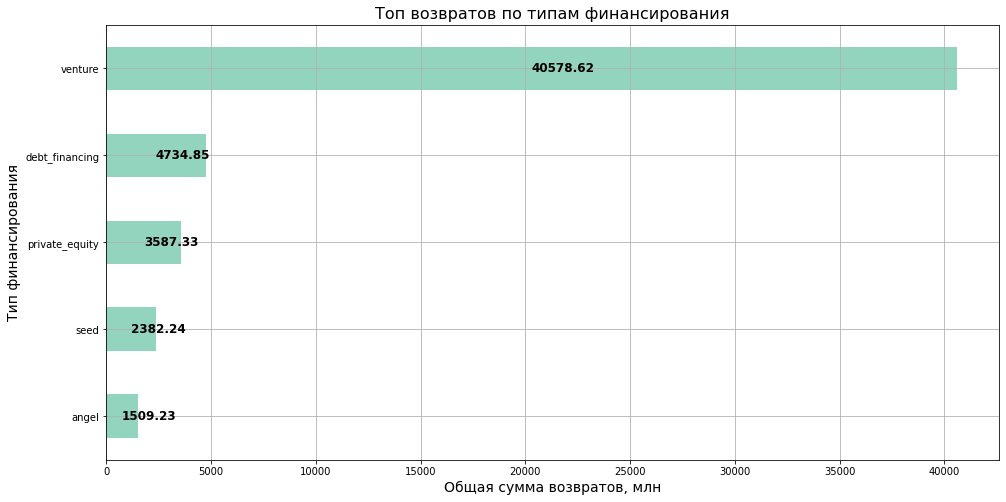

In [70]:
returns_by_types = returns_by_types.sort_values(by='Общая сумма возвратов').tail(5)

ax = returns_by_types.plot(
    kind='barh',
    x='Тип финансирования', 
    y='Общая сумма возвратов', 
    color='#66c2a5', 
    alpha=0.7, 
    legend=False,
    figsize=(16,8)
)

for patch in ax.patches:
    width = patch.get_width().astype('float64')
    y = patch.get_y() + patch.get_height() / 2 
    ax.text(
        width * 0.5,
        y, 
        f'{width:.2f}',
        ha='left', 
        va='center', 
        color='black',
        fontsize=12,
        fontweight='bold'
    )
plt.xlabel('Общая сумма возвратов, млн', fontsize=14)
plt.ylabel('Тип финансирования', fontsize=14)
plt.title('Топ возвратов по типам финансирования', fontsize=16)
plt.grid()

plt.show()

**Промежуточный вывод:**

Нулевое значение возвратов в инвестициях типа `grant` вполне обоснованно, так как гранты являются безвозмездными средствами, не требующими возврата при соблюдении условий.

Топ возвратов по типам финансирования практически совпадает с топом по объемам инвестиций - первую позицию так же занимает венчурное инвестирования с общим объемом возвратов более 40 млрд долларов. Это говорит о том, что венчурные инвестиции являются основой инвестиционного рынка, инвестируя в компании с высокой доходностью.

Также высокие объемы возвратов наблюдаются в типах:
`debt_financing` занимает третье место по объемам и частоте, и второе по сумме возвратов, что тоже говорит об эффективности этого инструмента, хоть и не в таких больших объемах, ка венчурные инвестиции.

`seed` находится на второй позции по объемам и частоте, но возвраты для этого типа инвестиций сильно ниже остальных из топа, можно предположить, что посевные инвестиции используются очень часто, но разовая сумма небольшая, и для новых компаний, доходность которых еще неизвестна либо ее может и не быть вовсе. То же можно сказать и про `angel` - высокая частота, но небольшие суммы и очень малые возвраты.

`private_equiity` характеризуются редкостью (не в топе по частоте), но значительными суммами и высокими возвратами - частные инвесторы вкладываются в компании редко, но с большой долей уверенности в успехе.

## Анализ динамики

### Динамика предоставления финансирования по годам

**Подготовка данных**

In [71]:
cb_investments['mean_per_round'] = cb_investments['funding_total_usd'] / cb_investments['funding_rounds']
cb_investments['mean_per_round'] = cb_investments['mean_per_round'].replace([np.inf, -np.inf], np.nan) 

median_per_round = cb_investments.groupby('funding_year')['mean_per_round'].median().reset_index()
median_per_round['mean_per_round'] = median_per_round['mean_per_round'] / 1000000

In [72]:
rounds_per_year = cb_investments.groupby('funding_year')['funding_rounds'].sum().reset_index()

**Годовая активность по среднему объему одного раунда финансирования и количеству раундов финансирования**

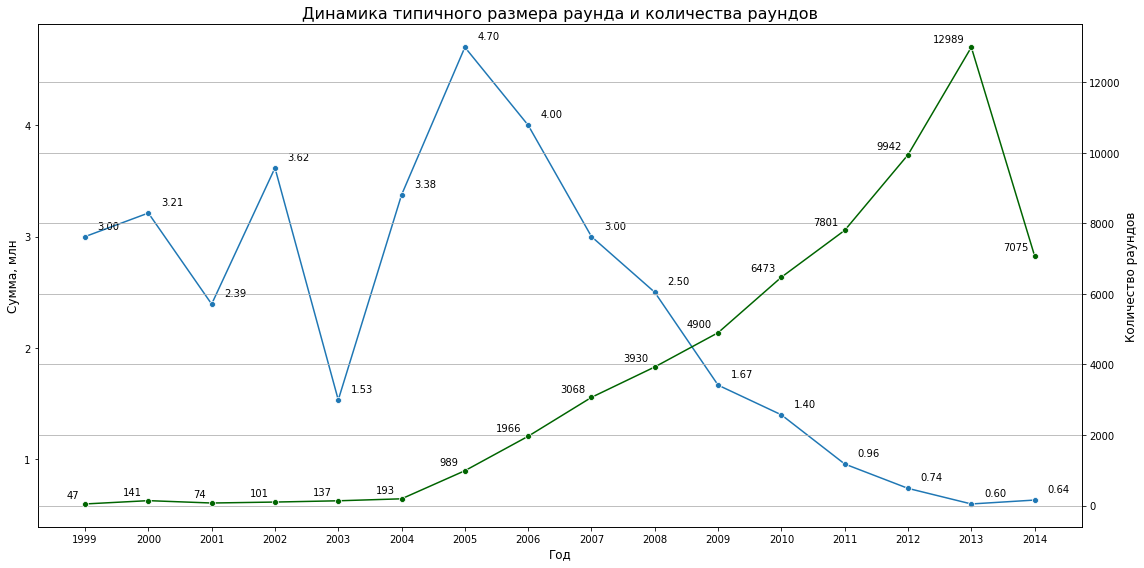

In [73]:
plt.figure(figsize=(16,8))

ax = sns.lineplot(
    data=median_per_round,
    x='funding_year',
    y='mean_per_round',
    marker='o'
)

for x, y in zip(median_per_round['funding_year'], median_per_round['mean_per_round']):
    ax.text(
        x + 0.2, 
        y + 0.07, 
        f'{y:.2f}', 
        ha='left'
    )


ax2 = ax.twinx() 

sns.lineplot(
    data=rounds_per_year,
    x='funding_year',
    y='funding_rounds',
    marker='o',
    color='darkgreen',
    ax=ax2
)

for x, y in zip(rounds_per_year['funding_year'], rounds_per_year['funding_rounds']):
    ax2.text(
        x - 0.1, 
        y + 100, 
        f'{y:.0f}', 
        ha='right',
        va='bottom',
        color='black'
    )


ticks = [1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009,
       2010, 2011, 2012, 2013, 2014]
ax.set_xticks(ticks)



ax.set_xlabel('Год', fontsize=12)
ax.set_ylabel('Сумма, млн', fontsize=12)
ax2.set_ylabel('Количество раундов', fontsize=12)

plt.title('Динамика типичного размера раунда и количества раундов', fontsize=16)
plt.grid()
plt.tight_layout()
plt.show()

**Промежуточный вывод:**
На графике заметна меняющаяся от года к году динамика типичного размера средств одного раунда финансирования в период с 1999 по 2003 годы - чередуются подьемы и спады.

Далее в период с 2003 по 2005 год типичный размер средств растет и достигает пика в 5 млн долларов за раунд в 2005 году. Начиная с 2006 года значения имеют отрицательную динамику, уменьшаясь от года к году и достигая минимума в 650 тысяч долларов в 2013 году.

В 2014 году типичный размер средств одного раунда финансирования увеличился до 700 тысяч долларов, однако все равно оставаясь одним из самых низких за рассматриваемый период.

По количеству раундов заметны небольшие колебания в активности в период с 1999 по 2004 годы - количество раундов финансирования ежегодно находилось в пределах от 58 до 258 раундов в год. Начиная с 2005 года наблюдается сильный рост активности по годам, достигший своего пика в 2013 году, когда было проведено 13465 раундов финансирования за год. Однако в 2014 году раундов финансирования прошло вдвое меньше - 7246.

Динамика снижения сумм инвестиций за раунд и увеличения количества раундов финансирования с 2005 года может говорить о том, что начиная с 2005 года на рынок стало приходить больше новых компаний (следовательно больше раундов финансирования), но так как успешность новых компаний еще неизвестна, то суммы финансирования для них меньше, что снижает типичную сумму раунда.

2014 год относительно предыдущего характеризуется повышением типичного размера средств, получаемых стартапами за один раунд финансирования, вместе со снижением общего количества разперов раунда за год, что может говорить о снижении количества новых стартапов на рынке.

### Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

In [74]:
pivot_funding = pd.pivot_table(
    cb_investments, 
    values='funding_total_usd', 
    index=['funding_year', 'market'], 
    aggfunc='sum'
)
pivot_funding

funding_total_usd
funding_year market                        
1999         advertising           350000.0
             analytics           10774916.0
             consulting            115200.0
             curated web          9250000.0
             e-commerce          39400000.0
...                                     ...
2014         startups            41501837.0
             technology         202016937.0
             travel              78920274.0
             video               75295943.0
             web hosting         56628619.0

[630 rows x 1 columns]

In [75]:
pivot_funding = pivot_funding.unstack(level=0)

growth_markets = pivot_funding[pivot_funding['funding_total_usd'][2014] > pivot_funding['funding_total_usd'][2013]].index

In [76]:
#исключаю нишевые и средние рынки, а также рынки nan
remove = ['mid', 'niche', 'nan']

growth_markets = growth_markets[~growth_markets.isin(remove)]

growth_markets

Index(['apps', 'design', 'internet', 'medical', 'messaging', 'real estate',
       'saas', 'sports', 'startups', 'technology', 'video'],
      dtype='object', name='market')

In [77]:
pivot_funding = pivot_funding.loc[growth_markets]
pivot_funding

funding_total_usd                                                 \
funding_year              1999        2000        2001        2002       2003   
market                                                                          
apps                       NaN         NaN         NaN         NaN        NaN   
design                     NaN         NaN         NaN         NaN        NaN   
internet                   NaN  10000000.0         NaN   1100000.0        NaN   
medical                    NaN  24000000.0         NaN         NaN        NaN   
messaging                  NaN  21350000.0         NaN  10000000.0        NaN   
real estate           250000.0   2500000.0         NaN   5275000.0  6292200.0   
saas                       NaN         NaN         NaN   2000000.0        NaN   
sports                     NaN         NaN         NaN    200000.0        NaN   
startups                   NaN         NaN         NaN         NaN        NaN   
technology           6000000.0         NaN  22160000.0  11000000.0        NaN   
video                      NaN         NaN         NaN         NaN  5000000.0   

                                                                              \
funding_year        2004         2005         2006         2007         2008   
market                                                                         
apps                 NaN          NaN    1310600.0          NaN    4300000.0   
design               NaN    9300000.0     707000.0   10800000.0    5944302.0   
internet      10500000.0    1775000.0          NaN    4495379.0   23412964.0   
medical              NaN   11090000.0   20250000.0    2100000.0   28812744.0   
messaging     13300000.0  154917020.0  145133772.0   96670099.0   67854600.0   
real estate          NaN     250000.0    2080000.0   33220000.0   46613100.0   
saas                 NaN    5240000.0    4791121.0   14652595.0   27226900.0   
sports               NaN    1882200.0    7000000.0   32401580.0   16940290.0   
startups             NaN          NaN          NaN          NaN    5010387.0   
technology     1750000.0   50728425.0   89977715.0  249617003.0  338226238.0   
video         14704000.0    6470551.0   55321772.0   85150644.0   37865177.0   

                                                                               \
funding_year         2009         2010         2011         2012         2013   
market                                                                          
apps           12705842.0    6123779.0   24374071.0   32593625.0   34806356.0   
design          2150144.0   17239975.0    8899967.0   39630692.0   60949509.0   
internet       38195773.0   36657500.0   36856532.0   40738685.0   83132096.0   
medical        11566200.0   52540338.0   28540962.0  122964483.0   64469424.0   
messaging      70002508.0   59716947.0  156649095.0   50335027.0   28864010.0   
real estate    38840213.0   37344608.0   20015128.0   77320857.0  106804655.0   
saas           13536585.0   32599390.0   53914660.0   60499912.0   90370613.0   
sports         11808750.0   38184989.0   24184258.0   48335868.0   36208524.0   
startups         460700.0    2110966.0   25654403.0   12358782.0   24079552.0   
technology    103078850.0  312526805.0  143222700.0  193334875.0  120873887.0   
video          41305584.0   79974203.0   26332122.0   54943470.0   68222106.0   

                           
funding_year         2014  
market                     
apps           66227730.0  
design         68988515.0  
internet      130655982.0  
medical       201735564.0  
messaging      39732287.0  
real estate   115565729.0  
saas          102795752.0  
sports         41454111.0  
startups       41501837.0  
technology    202016937.0  
video          75295943.0

На сводной таблице видно, что наиболее полные данные по растущим рынкам представлены начиная с 2008 года - для построения графика использую этот период.

In [78]:
pivot_funding = pivot_funding.loc[:, pivot_funding.columns.get_level_values(1) >= 2008]

pivot_funding

funding_total_usd                                         \
funding_year              2008         2009         2010         2011   
market                                                                  
apps                 4300000.0   12705842.0    6123779.0   24374071.0   
design               5944302.0    2150144.0   17239975.0    8899967.0   
internet            23412964.0   38195773.0   36657500.0   36856532.0   
medical             28812744.0   11566200.0   52540338.0   28540962.0   
messaging           67854600.0   70002508.0   59716947.0  156649095.0   
real estate         46613100.0   38840213.0   37344608.0   20015128.0   
saas                27226900.0   13536585.0   32599390.0   53914660.0   
sports              16940290.0   11808750.0   38184989.0   24184258.0   
startups             5010387.0     460700.0    2110966.0   25654403.0   
technology         338226238.0  103078850.0  312526805.0  143222700.0   
video               37865177.0   41305584.0   79974203.0   26332122.0   

                                                     
funding_year         2012         2013         2014  
market                                               
apps           32593625.0   34806356.0   66227730.0  
design         39630692.0   60949509.0   68988515.0  
internet       40738685.0   83132096.0  130655982.0  
medical       122964483.0   64469424.0  201735564.0  
messaging      50335027.0   28864010.0   39732287.0  
real estate    77320857.0  106804655.0  115565729.0  
saas           60499912.0   90370613.0  102795752.0  
sports         48335868.0   36208524.0   41454111.0  
startups       12358782.0   24079552.0   41501837.0  
technology    193334875.0  120873887.0  202016937.0  
video          54943470.0   68222106.0   75295943.0

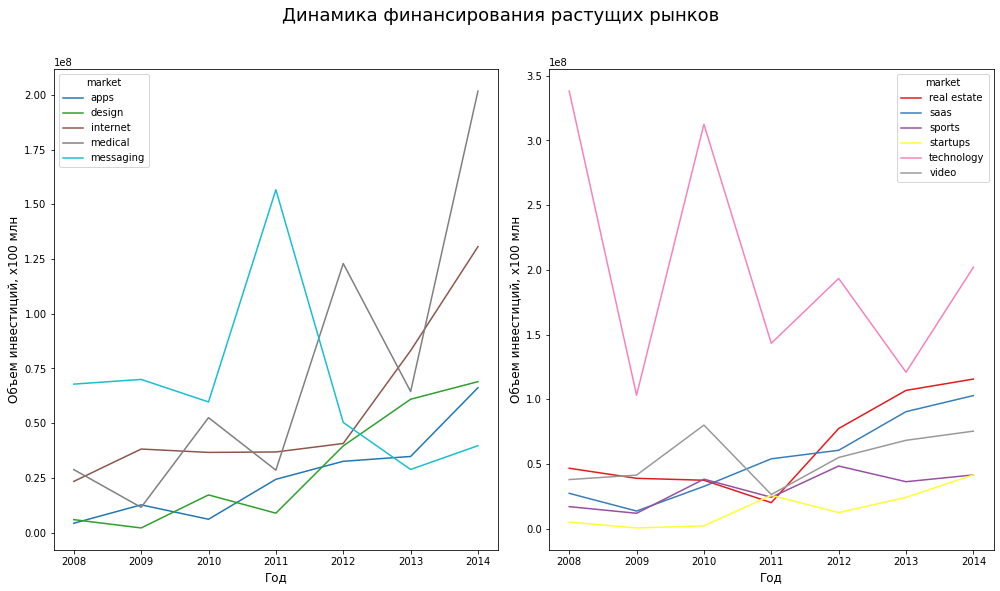

In [79]:
years = pivot_funding.columns.get_level_values(1)

#разделю данные по рынкам на два графика для лучшей визуалиации
markets_0 = ['apps','design','internet','medical','messaging']
pivot_funding_0 = pivot_funding.loc[markets_0]

markets_1 = ['real estate','saas','sports','startups', 'technology', 'video']
pivot_funding_1 = pivot_funding.loc[markets_1]


fig, axes = plt.subplots(1, 2, figsize=(22, 8))

axes[0] = pivot_funding_0.T.plot(
    figsize=(14,8),
    ax = axes[0],
    colormap='tab10'
)
axes[0].set_xticks(range(len(years)))
axes[0].set_xticklabels(years)
axes[0].set_xlabel('Год', fontsize=12)
axes[0].set_ylabel('Объем инвестиций, x100 млн', fontsize=12)

axes[1] = pivot_funding_1.T.plot(
    figsize=(14,8),
    ax = axes[1],
    colormap='Set1'
)
axes[1].set_xticks(range(len(years)))
axes[1].set_xticklabels(years)
axes[1].set_xlabel('Год', fontsize=12)
axes[1].set_ylabel('Объем инвестиций, x100 млн', fontsize=12)

plt.suptitle(f'Динамика финансирования растущих рынков', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

**Промежуточный вывод:**

На графиках видно, что наиболее стабильный и уверенный рост за период с 2008 по 2014 годы показывают рынки *apps, internet, startups и saas (software as a service)*. Остальные рынки, отобранные для графиков, на протяжении периода показывали нестабильные результаты по объемам финансирования, что видно по хаотичному движению их линейных графиков. Также для большинства представленных рынков визуализируется достаточно резкий одновременный спад объемов финансирования в 2011 году, что может говорить о реакции на изменения в экономике в тот период.

### Годовая динамика доли возвращённых средств по типам финансирования

**Свод возвратов по годам и типам финансирования**

In [80]:
cols = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note',
    'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity',
    'post_ipo_debt', 'secondary_market', 'product_crowdfunding'
]

pivot_funding_types = pd.pivot_table(
    cb_investments, 
    values=cols, 
    index='funding_year', 
    aggfunc='sum'
)

#разделю все на миллион для одинакового представления с возвратами
pivot_funding_types = pivot_funding_types / 1000000
pivot_funding_types.head()

,angel,convertible_note,debt_financing,equity_crowdfunding,grant,post_ipo_debt,post_ipo_equity,private_equity,product_crowdfunding,secondary_market,seed,undisclosed,venture
funding_year,,,,,,,,,,,,,
1999,1.200000,0.0,0.350000,0.0,0.000000,0.0,0.000000,3.000000,0.0,0.000000,13.536493,38.200000,111.239814
2000,26.086333,0.0,14.000000,0.0,0.293114,0.0,3.467747,0.000000,0.0,7.718867,16.758140,210.402640,402.258152
2001,1.000000,1.5,5.829217,0.0,0.100000,0.0,0.000000,0.000000,0.0,0.000000,2.667675,42.899893,353.994044
2002,3.000000,0.0,15.309671,0.0,0.000000,0.0,0.300000,7.500000,0.0,0.000000,10.465192,42.323731,330.940622
2003,5.629661,0.0,3.050000,0.0,16.850717,0.0,0.000000,20.869746,0.0,0.000000,15.318355,10.280000,439.834425


In [81]:
pivot_returns_types = pd.pivot_table(
    cb_returns, 
    values=cols, 
    index='year', 
    aggfunc='sum'
)
pivot_returns_types.head()

,angel,convertible_note,debt_financing,equity_crowdfunding,grant,post_ipo_debt,post_ipo_equity,private_equity,product_crowdfunding,secondary_market,seed,undisclosed,venture
year,,,,,,,,,,,,,
2000,6.43,0.00,8.66,0.0,0.0,0.0,0.94,0.00,0.0,0.20,16.70,78.21,55.40
2001,1.18,0.01,4.49,0.0,0.0,0.0,0.46,0.00,0.0,0.46,2.88,21.50,23.49
2002,3.41,0.02,3.42,0.0,0.0,0.0,0.34,1.51,0.0,0.06,6.59,25.77,209.42
2003,3.41,0.01,1.09,0.0,0.0,0.0,2.11,1.62,0.0,0.08,7.74,9.40,233.86
2004,9.18,0.01,13.55,0.0,0.0,0.0,3.38,2.19,0.0,0.55,9.93,33.19,555.90


In [82]:
fundings_returns = pivot_funding_types.join(pivot_returns_types, how='inner', lsuffix='_funding', rsuffix='_return')
fundings_returns.head()

,angel_funding,convertible_note_funding,debt_financing_funding,equity_crowdfunding_funding,grant_funding,post_ipo_debt_funding,post_ipo_equity_funding,private_equity_funding,product_crowdfunding_funding,secondary_market_funding,seed_funding,undisclosed_funding,venture_funding,angel_return,convertible_note_return,debt_financing_return,equity_crowdfunding_return,grant_return,post_ipo_debt_return,post_ipo_equity_return,private_equity_return,product_crowdfunding_return,secondary_market_return,seed_return,undisclosed_return,venture_return
2000,26.086333,0.0,14.000000,0.0,0.293114,0.0,3.467747,0.000000,0.0,7.718867,16.758140,210.402640,402.258152,6.43,0.00,8.66,0.0,0.0,0.0,0.94,0.00,0.0,0.20,16.70,78.21,55.40
2001,1.000000,1.5,5.829217,0.0,0.100000,0.0,0.000000,0.000000,0.0,0.000000,2.667675,42.899893,353.994044,1.18,0.01,4.49,0.0,0.0,0.0,0.46,0.00,0.0,0.46,2.88,21.50,23.49
2002,3.000000,0.0,15.309671,0.0,0.000000,0.0,0.300000,7.500000,0.0,0.000000,10.465192,42.323731,330.940622,3.41,0.02,3.42,0.0,0.0,0.0,0.34,1.51,0.0,0.06,6.59,25.77,209.42
2003,5.629661,0.0,3.050000,0.0,16.850717,0.0,0.000000,20.869746,0.0,0.000000,15.318355,10.280000,439.834425,3.41,0.01,1.09,0.0,0.0,0.0,2.11,1.62,0.0,0.08,7.74,9.40,233.86
2004,11.013741,0.0,30.816623,0.0,10.363600,0.0,0.000000,0.000000,0.0,0.000000,18.094728,62.912359,856.940451,9.18,0.01,13.55,0.0,0.0,0.0,3.38,2.19,0.0,0.55,9.93,33.19,555.90


In [83]:
#Рассчитываю доли по каждому типу финансирования
for c in cols:
    funding_col = f'{c}_funding'
    return_col  = f'{c}_return'
    ratio_col = f'{c}_ratio'
    fundings_returns[ratio_col] = fundings_returns[return_col] / (fundings_returns[funding_col]+1e-60)

In [84]:
#удаляю аномалии
for c in cols:
    r = fundings_returns[f'{c}_ratio']
    q1 = r.quantile(0.25)
    q3 = r.quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 2 * iqr
    fundings_returns.loc[r > upper, f'{c}_ratio'] = np.nan

In [85]:
fundings_returns = fundings_returns.round(4)
fundings_returns

,angel_funding,convertible_note_funding,debt_financing_funding,equity_crowdfunding_funding,grant_funding,post_ipo_debt_funding,post_ipo_equity_funding,private_equity_funding,product_crowdfunding_funding,secondary_market_funding,seed_funding,undisclosed_funding,venture_funding,angel_return,convertible_note_return,debt_financing_return,equity_crowdfunding_return,grant_return,post_ipo_debt_return,post_ipo_equity_return,private_equity_return,product_crowdfunding_return,secondary_market_return,seed_return,undisclosed_return,venture_return,seed_ratio,venture_ratio,equity_crowdfunding_ratio,undisclosed_ratio,convertible_note_ratio,debt_financing_ratio,angel_ratio,grant_ratio,private_equity_ratio,post_ipo_equity_ratio,post_ipo_debt_ratio,secondary_market_ratio,product_crowdfunding_ratio
2000,26.0863,0.0000,14.0000,0.0000,0.2931,0.0000,3.4677,0.0000,0.0000,7.7189,16.7581,210.4026,402.2582,6.43,0.00,8.66,0.00,0.0,0.00,0.94,0.00,0.00,0.20,16.70,78.21,55.40,0.9965,0.1377,0.0000,0.3717,0.000000e+00,0.6186,0.2465,0.0,0.0000,0.2711,0.0000,2.590000e-02,0.0000
2001,1.0000,1.5000,5.8292,0.0000,0.1000,0.0000,0.0000,0.0000,0.0000,0.0000,2.6677,42.8999,353.9940,1.18,0.01,4.49,0.00,0.0,0.00,0.46,0.00,0.00,0.46,2.88,21.50,23.49,1.0796,0.0664,0.0000,0.5012,6.700000e-03,0.7703,1.1800,0.0,0.0000,NaN,0.0000,4.600000e+59,0.0000
2002,3.0000,0.0000,15.3097,0.0000,0.0000,0.0000,0.3000,7.5000,0.0000,0.0000,10.4652,42.3237,330.9406,3.41,0.02,3.42,0.00,0.0,0.00,0.34,1.51,0.00,0.06,6.59,25.77,209.42,0.6297,0.6328,0.0000,0.6089,NaN,0.2234,1.1367,0.0,0.2013,1.1333,0.0000,6.000000e+58,0.0000
2003,5.6297,0.0000,3.0500,0.0000,16.8507,0.0000,0.0000,20.8697,0.0000,0.0000,15.3184,10.2800,439.8344,3.41,0.01,1.09,0.00,0.0,0.00,2.11,1.62,0.00,0.08,7.74,9.40,233.86,0.5053,0.5317,0.0000,0.9144,1.000000e+58,0.3574,0.6057,0.0,0.0776,NaN,0.0000,8.000000e+58,0.0000
2004,11.0137,0.0000,30.8166,0.0000,10.3636,0.0000,0.0000,0.0000,0.0000,0.0000,18.0947,62.9124,856.9405,9.18,0.01,13.55,0.00,0.0,0.00,3.38,2.19,0.00,0.55,9.93,33.19,555.90,0.5488,0.6487,0.0000,0.5276,1.000000e+58,0.4397,0.8335,0.0,NaN,NaN,0.0000,5.500000e+59,0.0000
2005,62.4146,0.0000,106.2207,0.0000,6.2665,0.0000,4.7960,5.0000,0.0000,0.0000,39.4106,26.6622,5277.2934,31.06,0.02,35.09,0.00,0.0,0.00,3.51,2.40,0.00,0.05,26.60,9.51,2628.92,0.6749,0.4982,0.0000,0.3567,NaN,0.3304,0.4976,0.0,0.4800,0.7319,0.0000,5.000000e+58,0.0000
2006,71.7562,10.7024,199.3965,0.9331,6.1475,0.0000,38.0071,121.5159,0.0000,0.0000,67.7042,61.5455,10284.2842,47.75,1.78,113.21,0.19,0.0,0.00,20.58,16.67,0.00,0.12,61.81,46.74,3100.18,0.9129,0.3014,0.2036,0.7594,1.663000e-01,0.5678,0.6654,0.0,0.1372,0.5415,0.0000,1.200000e+59,0.0000
2007,217.6344,14.1168,310.5331,0.0000,52.7378,0.0000,12.0000,153.3702,0.0000,0.0000,216.5603,158.5893,14039.6278,164.51,3.22,125.68,0.01,0.0,0.00,24.36,88.81,0.00,0.57,70.41,55.37,3585.37,0.3251,0.2554,NaN,0.3491,2.281000e-01,0.4047,0.7559,0.0,0.5791,2.0300,0.0000,5.700000e+59,0.0000
2008,249.7940,28.7509,503.3895,0.0000,23.4853,0.0000,36.0000,212.7563,1.0000,0.0000,314.5191,131.8823,16749.4460,102.83,1.71,397.54,0.03,0.0,0.00,84.28,130.38,0.00,0.47,89.72,41.02,2717.02,0.2853,0.1622,NaN,0.3110,5.950000e-02,0.7897,0.4117,0.0,0.6128,2.3411,0.0000,4.700000e+59,0.0000
2009,169.5782,80.2374,1173.5042,2.0497,305.8180,0.0908,93.5824,360.3696,0.3030,19.3000,292.7071,143.0877,17508.7348,97.21,2.25,394.10,0.18,0.0,0.00,76.76,203.70,0.02,0.12,160.21,37.50,2501.29,0.5473,0.1429,0.0878,0.2621,2.800000e-02,0.3358,0.5732,0.0,0.5653,0.8202,0.0000,6.200000e-03,NaN


----

**Визуализация возврата средств**

Целевые типы финансирования - `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

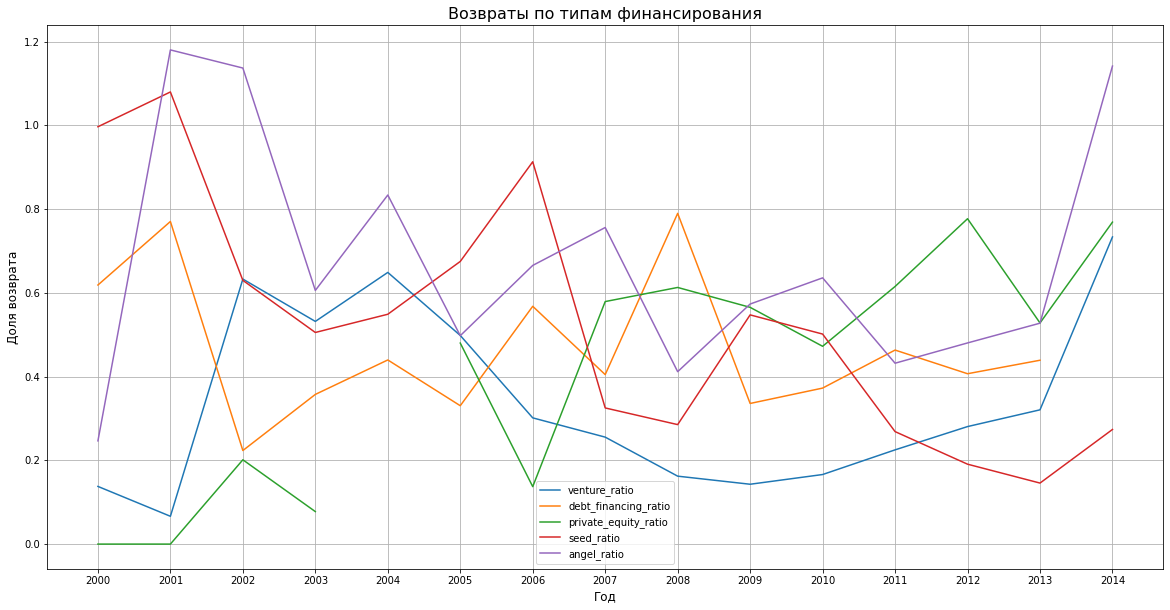

In [86]:
target_types = ['venture_ratio', 'debt_financing_ratio', 'private_equity_ratio', 'seed_ratio', 'angel_ratio']

plt.figure(figsize=(20, 10))

for col in target_types:
    plt.plot(fundings_returns.index, fundings_returns[col], label=col)

ticks = [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009,
       2010, 2011, 2012, 2013, 2014]

plt.xticks(ticks)
plt.title('Возвраты по типам финансирования', fontsize=16)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Доля возврата', fontsize=12)
plt.grid()
plt.legend()
plt.show()

**Промежуточный вывод:**

На графике видно, что наиболее устойчивыми с точки зрения возвратов являются инвестиции типа `venture` и `private_equity` - их линйеные графики наиболее стабильны на всем протяжении периода с 2000 по 2014 годы, без резких скачков, как например у инвестиций `angel`. Наиболее явную тенденцию роста можно отследить у `private equity` - немсотря на небольшие спады, линия графика устойчиво стремится вверх. Инвестиции `venture` имеют положительную динамику возвратов начиная с 2009 года.

Однако изменения доли возвратов по типам финансирования (как положительные, так и отрицательные) не могут стопроцентно говорить об эффективности данных типов, так как на это еще могут влиять другие показатеели - например доля инвестиций от общего, где при увеличении объема инвестиций растет доля возвратов, это еще не говорит о том, что инструмент стал эффективнее. 


## Итоговый вывод и рекомендации

**Целью исследования** являяется исследование динамики и структуры финансирования стартапов и оценка инвестиционных стратегий.

В рамках данного исследования были использованы датасеты с информацией о компаниях и состоявшемся финансировании и информацией об объёмах возвратов по годам и типам финансирования. 

**Этапы подготовки к исследованию:**
1. Получена общая информация о датасетах, выведены первые строки данных для ознакомления. Датасет `cb_investments` содержит 54294 строки и 40 столбцов. Датасет `cb_returns` содержит 15 строк и 14 столбцов.
2. Произведены преобразования типов данных для столбцов с числовыми данными и датами. Произведено преобразование наименований столбцов и их значений к нижнему регистру, удалены лишние пробелы.
3. Выявлены и исключены из датасета `cb_investments` 4855 строк-явных дубликатов, также удалены строки, не содержащие данных об объемах финансирования `funding_total_usd` и строки, не содержащие значений ни в одном из столбцов.
4. Заменены пропуски в столбце `mid_funding_at` на значение, равное середине интервала между `first_funding_at` и `last_funding_at`.
5. В датасете `cb_returns` столбец с годом установлен как индекс датасета.
3. Визуализированы пропуски с помощью матрицы пропусков в данных и тепловой карты корреляции пропусков. Пропуски в столбцах `founded_at`, `founded_month`, `founded_quarter`, `founded_year` отнесены к категории MAR и не были удалены. Пропуски в столбцах `first_funding_at` и `mid_funding_at` так же относены к категории MAR и были удалены, так как строк с пропусками в этих столбцах ничтожное количество в масштабе датасета. Пропуски в столбцах `homepage_url` и `participants` относены к категории MCAR и не были удалены из датасета.
5. В процессе предобработки из датасета `cb_investments` исключено 24.66% строк. После предобработки данных датасет `cb_investments` состоит из 40905 строк и 40 столбцов, датасет `cb_returns` состоит из 15 строк и 14 столбцов.

**Этапы исследования:**

1. Выделены три группы компаний по срокам финансирования, проведено их сравнение по количеству компаний в группах и объёму привлеченных инвестиций. Рынок характеризуется высокой долей единоразовых инвестиций, однако больше половины всех средств сосредоточено у компаний с длительным сроком финансирования. Можно предположить, что большая часть денег инвестируется преимущественно в более зрелые или стратегически перспективные компании, а единичное финансирование относится к недавно вышедшим на рынок компаниям, доходность которых еще не понятна. Более половины компаний (59.4%) получали *единичное финансирование*, чуть меньше трети компаний (30.1%) получали последнее финансирования *спустя больше года после первого финансирования*. У оставшихся 10.6% компаний между первым и последним финансированием *прошло менее года*. Несмотря на то, что большая часть компаний получали единичное финансирование, основной объем средств (61.9%) приходится на компании, у которых срок финансирования составляет более года. Чуть меньше трети от объема всех средств (30.9%) получали компании с единичным финансированием, а остаток (7.2%) приходится на компании, у которых срок финансирования до года. 


2. Сегменты рынка разделены на массовые, средние и нишевые в зависимости от количества компаний в этих рынках. Отрасли с более 120 компаниями отнесены к массовому сегменту, с менее 35 компаний - к нишевому сегменту, остальные - к среднему. Большая часть отраслей относится к *нишевому сегменту (289 отраслей включающих 830 компаний), далее идет средний сегмент (57 отраслей включающих 3839 компаний) и массовый (49 отраслей включающих 36236 компаний)*. В нишевом сегмете большинство отраслей включают 1-2 компании, явное правоассимметриченое распределение значений. В среднем сегменте распределение отраслей по количеству компаний более равномерное. Несмотря на то, что к массовому сегменту рынков относится наибольшее количество компаний (36236), самих рынков в разрезе сегмента выделено наименьшее количество. У нишевого сегмента ситуация обратно пропорциональная - при небольшом количестве компаний этот сегмент самый разнообразный по количеству направлений (830 компаний на 239 рынках). Это может говорить о том, что в массовом сегменте большая конкуренция в рамках одного рынка, а вот в нишевом сегменте рынки достаточно узкие, представленные малым количеством компаний.


3. Определено распределение компаний по объемам финансирования, выявлены типичные и аномальные значения объёмов финансирования, рассчитаны пороги выбросов для исключения аномальных значений. На диаграмме размаха и графике распределения явно визуализируется правоассимметричное распределение значений. Основная часть значений объема финансирования - до 10.000.000 долларов (75 перцентиль, правая граница "ящика"). Медианное значение смещено влево в "ящике", что говорит о том что большая часть объемов финансирования находятся около отметки в 2.000.000 долларов. На основании визуальной оценки можно сказать, что типичным объемом финансирования для компаний является сумма до USD 25.000.000.


4. Определены сегменты рынка по наибольшей доли компаний с аномальным финансированием, исключены аномальные значения из датасета. В среднем сегменте рынков больше всего компаний, имеющих аномальное финансирование - почти 11%. Нишевый сегмент рынков закрывает топ-10 по аномальному финансированию с долей таких компаний в 2.6%. Из компаний массового сегмента наибольшая доля аномальных финансирований приходится на рынок software. Также можно отметить, что среди компаний, для которых не указан рынок, доля компаний с аномальным финансированием также высока и составляет 7.2%.


5. Была произведена проверка полноты данных за 2014 год - в датасете содержатся данные за все 12 месяцев года, поэтому их можно считать полными. Из датасета были исключены компании, имеющие аномальное финансирование, границы которого были определены на предыдущем этапе (минимальный порог соотвествующий 1 перцентилю по рынку, а максимальный порог - 75 перцентиль с коэффициентом 2хIQR в разрезе сегмента рынка). Выделены и оставлены в датасете данные за 2000-2014 год - в эти годы количество раундов финансирования составляло 50 и более.


6. Выявлены наиболее популярные типы финансирования в зависимости от общих объемов привлеченных инвестиций и частоты появления инвестиций данных типов. При сравнении популярных типов финансирования заметно выделяется венчурное инвестирование - он является наиболее популярным типом и по объемам привлеченных инвестиций, и по частоте его использования компаниями. Долговое финансирование также удерживается в топе по обоим параметрам, являясь топ-2 по объемам привлеченных инвестиций и топ-3 по частоте использования. Также в обоих топах находится инвестирование на посевной стадии - топ-4 по объемам и топ-2 по частоте использования. Другие типы финансирования, привлекшие большие объемы инвестиций, уже не являются настолько часто встречающимися - прямые вложения привлекли более 12 млрд долларов инвестиций, однако использовались компаниями лишь 839 раз. Финансирование после IPO закрывает топ-5 по вложениям (более 4 млрд привлеченных инвестиций), но по частоте использования являются далеко не самым популярным типом финансирования среди компаний. Таким образом можно предположить, что подобные типы инвестиций обычно разово приносят больше вложений. Топ возвратов по типам финансирования практически совпадает с топом по объемам инвестиций - первую позицию так же занимает венчурное инвестирования с общим объемом возвратов более 40 млрд долларов. Также высокие объемы возвратов наблюдаются в типах debt_financing, private_equiity, seed и angel.


7. Определены типичные значения объемов финансирования на раунд в каждом году, визуализирована динамика изменения типичных объемов финансирования за раунд. Определена меняющаяся от года к году динамика типичного размера средств одного раунда финансирования в период с 1999 по 2003 годы - чередуются подьемы и спады. Далее в период с 2003 по 2005 год типичный размер средств растет и достигает пика в 5 млн долларов за раунд в 2005 году. Начиная с 2006 года значения имеют отрицательную динамику, уменьшаясь от года к году и достигая минимума в 650 тысяч долларов в 2013 году. В 2014 году типичный размер средств одного раунда финансирования увеличился до 700 тысяч долларов, однако все равно оставаясь одним из самых низких за рассматриваемый период.


8. Определено общее количество раундов финансирования в каждом году, визуализинрована динамика изменения количества раундов год к году. Выявлены небольшие колебания в активности в период с 1999 по 2004 годы - количество раундов финансирования ежегодно находилось в пределах от 58 до 258 раундов в год. Начиная с 2005 года наблюдается сильный рост активности по годам, достигший своего пика в 2013 году, когда было проведено 13465 раундов финансирования за год. Однако в 2014 году раундов финансирования прошло вдвое меньше - 7246. Таким образом, 2014 год относительно предыдущего характеризуется повышением типичного размера средств, получаемых стартапами за один раунд финансирования, вместе со снижением общего количества разперов раунда за год. Динамика снижения сумм инвестиций за раунд и увеличения количества раундов финансирования с 2005 года может говорить о том, что начиная с 2005 года на рынок стало приходить больше новых компаний (следовательно больше раундов финансирования), но так как успешность новых компаний еще неизвестна, то суммы финансирования для них меньше, что снижает типичную сумму раунда. 

9. Рассчитаны общие объемы привлеченных инвестиций для массовых сегментов рынка, визуализирована динамика изменения объемов привлеченных инвестиций в разрезе периода с наибольшей полнотой данных (2008-2014 годы). Наиболее стабильный и уверенный рост за период с 2008 по 2014 годы показывают рынки apps, internet, startups и saas (software as a service). Остальные рынки, отобранные для графиков, на протяжении периода показывали нестабильные результаты по объемам финансирования. Также для большинства представленных рынков визуализируется достаточно резкий одновременный спад объемов финансирования в 2011 году, что может говорить о реакции на изменения в экономике в тот период.


10. Рассчитана доля возврата средств для разных типов финансирования, визуализирована динамика изменения долей возврата для разных типов финансирования по годам, выявлены типы финансирования с наиболее стабильным и уверенным ростом доли возврата год к году. Наиболее устойчивыми с точки зрения возвратов являются инвестиции типа venture и private_equity. Наиболее явную тенденцию роста можно отследить у private equity.


**Выводы и рекомендации:**
1. Судя по анализу самые стабильные и прогнозируемые с точки зрения роста объемов привлеченных инвестиций рынки это apps, internet, startups и saas (software as a service). Все четыре рынка показывают стабильный рост финансирования, что говорит о рыночной активности, интересе со стороны инвесторов и наличии перспектив для роста.
2. Венчурные инвестиции являются наиболее частым типом финансирования и по частоте использования, по объему привлеченных инвестиций и доле возвратов. Также наиболее устойчивый рост доли возвратов можно отследить у прямых(частных) вложений.  

**В 2015 году оптимальными рынками для инвестиций являются рынки, связанные с информационными технологиями - интернет, приложения, технологические стартапы и SaaS-сервисы. Наиболее целесообразно в данном случае использовать венчурные инвестиции или прямые (частные) вложения как инструменты, демонстрирующие наиболее стабильный рост.**